# AI-Based Smart Irrigation System Using Environmental Sensor Data

Internship project — Data Science + AI for IoT Agriculture


## Step 1 — Project Introduction

### The problem
Irrigation is one of the largest uses of fresh water in agriculture. Farmers usually decide *when* to irrigate using experience, a fixed schedule or a quick visual check of the field. That is difficult because soil conditions change continuously with weather, crop stage and soil type, and they are not monitored continuously. Two failure modes follow:

Under-irrigation : the crop is stressed because water was applied too late or not at all, which can reduce yield.
Over-irrigation : water, energy and money are wasted, and nutrients can be washed out of the soil.

### The purpose of the smart irrigation system
Measure field conditions automatically and use those measurements to recommend (or trigger) irrigation only when it is needed.

### Role of sensors and AI
Component and Role

Sensors: Continuously measure conditions in the field.
Machine-learning model:Learns from historical labelled data how sensor readings relate to irrigation need, and turns new readings into a decision. 

### Model inputs (the three main sensor measurements)
1. Soil moisture
2. Temperatur
3. Humidity

### Expected output
A prediction of the field's irrigation need, which is then translated into a pump recommendation (irrigate / do not irrigate). The exact form of the target depends on what the uploaded dataset actually contains, and is established in Steps 3–4.

### Overall system
Sensors → Data Collection → Preprocessing → ML Model → Irrigation Prediction → Water Pump


 This notebook builds and evaluates the machine-learning prototype. Connecting it to physical sensors and a pump is a future stage (Step 19) and has not been implemented or tested here.


## Step 2 — Import Libraries

Only libraries that are actually needed are imported:

 Library and Use 
 
 `pandas`  Loading the CSV, cleaning, tabulating and summarising data 
 `numpy`  Numerical operations, random seeds 
`matplotlib`  Base plotting (histograms, bar charts, evaluation plots) 
 `seaborn`  Statistical plots (heatmaps, box plots) built on matplotlib 
 `scikit-learn` Train/test split, scaling, pipelines, models, cross-validation, metrics 
 `joblib`  Saving and loading the trained model 
 `json`, `pathlib`, `datetime`, `platform` Writing model metadata and handling file paths (standard library) 


In [5]:
import json
import platform
import warnings
from datetime import datetime
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score,
                             classification_report, confusion_matrix,
                             precision_recall_fscore_support)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold,
                                     cross_val_predict, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier, export_text

warnings.filterwarnings("ignore")          # keep the report output clean
RANDOM_STATE = 42                          # reproducibility everywhere
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold"})
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
print("pandas", pd.__version__, "| numpy", np.__version__, "| scikit-learn", sklearn.__version__)

pandas 2.2.2 | numpy 1.26.4 | scikit-learn 1.5.1


## Step 3 — Load the Dataset

The file is loaded first without assuming any column names. The commands below tell us:

 `shape`  how many rows (observations) and columns (variables) we have.
 `head()` / `tail()` what the records look like at the start and end of the file (units, formats, obvious ordering problems).
`columns`  the exact variable names.
`info()`  data types and non-null counts, which reveals missing values and wrongly-typed columns.


In [7]:
CANDIDATE_PATHS = [
    "irrigation_prediction.csv",                          # same folder as the notebook
       
]
DATA_PATH = next((p for p in CANDIDATE_PATHS if Path(p).exists()), None)
assert DATA_PATH is not None, "Dataset not found - put irrigation_prediction.csv next to the notebook."

df_raw = pd.read_csv(DATA_PATH)
print("Loaded from:", DATA_PATH)
print("Shape (rows, columns):", df_raw.shape)

Loaded from: irrigation_prediction.csv
Shape (rows, columns): (10000, 20)


In [3]:
print("First 5 rows"); display(df_raw.head())
print("Last 5 rows");  display(df_raw.tail())

First 5 rows


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Clay,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,Wheat,Vegetative,Rabi,Rainfed,Reservoir,4.73,Yes,1.98,South,Low
1,Silt,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,Maize,Flowering,Zaid,Canal,Groundwater,12.22,Yes,33.56,Central,Medium
2,Sandy,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,Cotton,Harvest,Rabi,Drip,Reservoir,5.52,Yes,34.62,South,Low
3,Clay,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,Wheat,Sowing,Kharif,Canal,Reservoir,1.43,Yes,84.03,North,Medium
4,Clay,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,Cotton,Sowing,Zaid,Canal,River,2.52,No,60.86,South,Medium


Last 5 rows


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
9995,Silt,7.01,26.67,0.86,0.76,27.61,52.20,1075.12,7.41,19.66,Sugarcane,Sowing,Kharif,Drip,Groundwater,2.62,Yes,92.44,South,Low
9996,Clay,5.40,49.44,0.90,1.19,34.03,52.31,1591.84,9.86,5.66,Maize,Sowing,Kharif,Rainfed,Groundwater,4.87,No,15.46,South,Low
9997,Loamy,4.97,60.63,0.99,1.30,36.68,68.16,2384.87,10.75,13.40,Potato,Harvest,Kharif,Canal,Groundwater,10.08,Yes,116.36,North,Low
9998,Loamy,7.12,44.33,1.56,1.08,31.50,64.83,2397.01,4.03,3.05,Sugarcane,Harvest,Kharif,Rainfed,Reservoir,11.11,Yes,118.17,East,Low
9999,Sandy,5.65,62.25,1.48,3.00,35.71,45.33,177.69,10.93,12.32,Potato,Harvest,Kharif,Canal,Rainwater,11.32,No,98.88,North,Medium


In [4]:
print("Column names:"); print(df_raw.columns.tolist()); print()
df_raw.info()

Column names:
['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare', 'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need']

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Soil_Type                10000 non-null  str    
 1   Soil_pH                  10000 non-null  float64
 2   Soil_Moisture            10000 non-null  float64
 3   Organic_Carbon           10000 non-null  float64
 4   Electrical_Conductivity  10000 non-null  float64
 5   Temperature_C            10000 non-null  float64
 6   Humidity                 10000 non-null  float64
 7   Rainfall_mm              10000 non-null  float64
 8   Sun

**Interpretation.** The file has **10,000 observations and 20 columns** (11 numerical, 9 text). Every column has 10,000 non-null values, so there are no missing entries. The columns cover soil properties, weather, crop information and management, and finish with `Irrigation_Need`. Latitude/longitude columns are absent (checked formally in Step 7).

## Step 4 — Understand the Dataset

### 4.1 Overview: types, missing values, duplicates, unique values


In [4]:
numeric_cols = df_raw.select_dtypes(include="number").columns.tolist()
categorical_cols = df_raw.select_dtypes(exclude="number").columns.tolist()

print(f"Observations (rows)      : {len(df_raw):,}")
print(f"Variables (columns)      : {df_raw.shape[1]}")
print(f"Numerical columns  ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical columns({len(categorical_cols)}): {categorical_cols}")
print(f"Total missing values     : {int(df_raw.isna().sum().sum())}")
print(f"Duplicate rows           : {int(df_raw.duplicated().sum())}")

overview = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing": df_raw.isna().sum(),
    "unique_values": df_raw.nunique(),
})
display(overview)

Observations (rows)      : 10,000
Variables (columns)      : 20
Numerical columns  (11): ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']
Categorical columns(9): ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region', 'Irrigation_Need']
Total missing values     : 0
Duplicate rows           : 0


,dtype,missing,unique_values
Soil_Type,object,0,4
Soil_pH,float64,0,341
Soil_Moisture,float64,0,4751
Organic_Carbon,float64,0,131
Electrical_Conductivity,float64,0,341
Temperature_C,float64,0,2897
Humidity,float64,0,5305
Rainfall_mm,float64,0,9813
Sunlight_Hours,float64,0,701
Wind_Speed_kmh,float64,0,1937


### 4.2 Basic statistics

In [5]:
display(df_raw.describe().T.round(2))
print("Categorical variables - category counts:")
for col in categorical_cols:
    print(f"  {col:18s}", df_raw[col].value_counts().to_dict())

,count,mean,std,min,25%,50%,75%,max
Soil_pH,10000.0,6.49,0.98,4.80,5.64,6.47,7.35,8.20
Soil_Moisture,10000.0,36.97,16.43,8.00,22.86,37.24,50.94,65.00
Organic_Carbon,10000.0,0.94,0.37,0.30,0.62,0.95,1.26,1.60
Electrical_Conductivity,10000.0,1.79,0.98,0.10,0.94,1.78,2.65,3.50
Temperature_C,10000.0,26.99,8.66,12.00,19.46,27.09,34.50,42.00
Humidity,10000.0,60.08,20.19,25.00,42.86,60.04,77.70,95.00
Rainfall_mm,10000.0,1252.50,715.58,0.38,634.16,1250.34,1880.26,2499.69
Sunlight_Hours,10000.0,7.52,2.02,4.00,5.76,7.56,9.26,11.00
Wind_Speed_kmh,10000.0,10.16,5.67,0.50,5.16,10.19,15.10,20.00
Field_Area_hectare,10000.0,7.60,4.23,0.30,3.95,7.54,11.20,15.00


Categorical variables - category counts:
  Soil_Type          {'Sandy': 2536, 'Silt': 2501, 'Loamy': 2486, 'Clay': 2477}
  Crop_Type          {'Rice': 1711, 'Maize': 1694, 'Sugarcane': 1678, 'Potato': 1663, 'Wheat': 1659, 'Cotton': 1595}
  Crop_Growth_Stage  {'Harvest': 2581, 'Vegetative': 2521, 'Flowering': 2465, 'Sowing': 2433}
  Season             {'Rabi': 3383, 'Kharif': 3362, 'Zaid': 3255}
  Irrigation_Type    {'Sprinkler': 2527, 'Rainfed': 2511, 'Drip': 2495, 'Canal': 2467}
  Water_Source       {'River': 2528, 'Reservoir': 2513, 'Rainwater': 2497, 'Groundwater': 2462}
  Mulching_Used      {'No': 5013, 'Yes': 4987}
  Region             {'South': 2102, 'West': 2017, 'East': 1994, 'Central': 1987, 'North': 1900}
  Irrigation_Need    {'Low': 5864, 'Medium': 3800, 'High': 336}


### 4.3 Identifying the columns we need

The dataset has no data dictionary, so columns are identified from their names and their value ranges:

Soil moisture → `Soil_Moisture` (range 8–65, consistent with a percentage).
Temperature → `Temperature_C` (range 12–42; the `_C` suffix indicates degrees Celsius).
Humidity → `Humidity` (range 25–95, consistent with relative humidity in %).
Irrigation requirement → `Irrigation_Need` – the only column describing irrigation status.

Assumption to confirm: the units (%, °C) are inferred, not documented. They should be confirmed with the data provider before real sensors are calibrated against this dataset.

Important finding about the target. `Irrigation_Need` is not binary. It has three ordered levels: Low, Medium, High. This is an original column supplied by the dataset (not a derived target), so the model will predict those three real labels. A pump ON/OFF recommendation is derived from the predicted level later (Step 17) using an explicit, editable rule.

All other columns (soil type, crop, season, region, rainfall, …) are documented below but are not used as model inputs, as required by the project brief.


In [6]:
SOIL_COL, TEMP_COL, HUM_COL = "Soil_Moisture", "Temperature_C", "Humidity"
TARGET_COL = "Irrigation_Need"
FEATURES = [SOIL_COL, TEMP_COL, HUM_COL]           # final model inputs (order matters!)
CLASS_ORDER = ["Low", "Medium", "High"]            # natural order of the target labels
OTHER_COLS = [c for c in df_raw.columns if c not in FEATURES + [TARGET_COL]]

print("FEATURE COLUMNS :", FEATURES)
print("TARGET COLUMN   :", TARGET_COL, "->", CLASS_ORDER)
print("Documented but NOT used in the model:", OTHER_COLS)

FEATURE COLUMNS : ['Soil_Moisture', 'Temperature_C', 'Humidity']
TARGET COLUMN   : Irrigation_Need -> ['Low', 'Medium', 'High']
Documented but NOT used in the model: ['Soil_Type', 'Soil_pH', 'Organic_Carbon', 'Electrical_Conductivity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare', 'Mulching_Used', 'Previous_Irrigation_mm', 'Region']


### 4.4 Distribution of the three sensor variables (numerical summary)

In [7]:
summary = df_raw[FEATURES].agg(["count", "mean", "median", "std", "min", "max", "skew"]).T.round(2)
display(summary)

,count,mean,median,std,min,max,skew
Soil_Moisture,10000.0,36.97,37.24,16.43,8.0,65.0,-0.04
Temperature_C,10000.0,26.99,27.09,8.66,12.0,42.0,-0.01
Humidity,10000.0,60.08,60.04,20.19,25.0,95.0,-0.01


**Interpretation.**

No missing values and no duplicate rows were found.
 The three sensor variables have means close to the middle of their ranges (soil moisture ≈ 37 %, temperature ≈ 27 °C, humidity ≈ 60 %) and mean ≈ median with skew ≈ 0. This suggests roughly symmetric, evenly spread distributions, confirmed in Step 6.
 The target `Irrigation_Need` is imbalanced: Low 5,864 · Medium 3,800 · High 336.
 Final selection: features = `Soil_Moisture`, `Temperature_C`, `Humidity`; target = `Irrigation_Need` (Low / Medium / High).

## Step 5 — Data Cleaning

Checks performed: missing values, duplicates, impossible values, data types and outliers.

Plausibility rules used for "impossible" values** (physical limits, not statistical ones):

| Variable | Valid range | Reason |
|---|---|---|
| Soil moisture | 0 – 100 % | It is a percentage |
| Humidity | 0 – 100 % | Relative humidity is a percentage |
| Temperature | −20 – 60 °C | Wider than any plausible agricultural air temperature |

Outliers are flagged, not deleted. The IQR rule (values beyond 1.5 × IQR outside the quartiles) only tells us a value is statistically unusual. Whether it is a genuine reading or a sensor fault needs a physical judgement, which is made below.


In [9]:
# --- 5.1 missing values, duplicates, types ---------------------------------
print("Missing values in model columns:\n", df_raw[FEATURES + [TARGET_COL]].isna().sum().to_string(), "\n")
print("Duplicate rows:", df_raw.duplicated().sum())
print("Numeric feature dtypes:", df_raw[FEATURES].dtypes.astype(str).to_dict())
print("Target labels found   :", sorted(df_raw[TARGET_COL].dropna().unique()), "(expected", CLASS_ORDER, ")")
print("Labels with stray whitespace/case issues:",
      int((df_raw[TARGET_COL].dropna() != df_raw[TARGET_COL].dropna().str.strip().str.title()).sum()))

Missing values in model columns:
 Soil_Moisture      0
Temperature_C      0
Humidity           0
Irrigation_Need    0 



Duplicate rows: 0
Numeric feature dtypes: {'Soil_Moisture': 'float64', 'Temperature_C': 'float64', 'Humidity': 'float64'}
Target labels found   : ['High', 'Low', 'Medium'] (expected ['Low', 'Medium', 'High'] )
Labels with stray whitespace/case issues: 0


In [8]:
# --- 5.2 impossible values --------------------------------------------------
PHYSICAL_LIMITS = {SOIL_COL: (0, 100), TEMP_COL: (-20, 60), HUM_COL: (0, 100)}
rows = []
for col, (lo, hi) in PHYSICAL_LIMITS.items():
    rows.append({"variable": col, "allowed_range": f"{lo} to {hi}",
                 "observed_min": df_raw[col].min(), "observed_max": df_raw[col].max(),
                 "violations": int(((df_raw[col] < lo) | (df_raw[col] > hi)).sum())})
display(pd.DataFrame(rows))

,variable,allowed_range,observed_min,observed_max,violations
0,Soil_Moisture,0 to 100,8.0,65.0,0
1,Temperature_C,-20 to 60,12.0,42.0,0
2,Humidity,0 to 100,25.0,95.0,0


In [9]:
# --- 5.3 statistical outliers (IQR rule) - flagged only ----------------------
def iqr_outlier_report(frame, cols):
    out = []
    for col in cols:
        q1, q3 = frame[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        out.append({"variable": col, "lower_fence": round(lo, 2), "upper_fence": round(hi, 2),
                    "n_outliers": int(((frame[col] < lo) | (frame[col] > hi)).sum()),
                    "rows_at_min": int((frame[col] == frame[col].min()).sum()),
                    "rows_at_max": int((frame[col] == frame[col].max()).sum())})
    return pd.DataFrame(out)

display(iqr_outlier_report(df_raw, FEATURES))

,variable,lower_fence,upper_fence,n_outliers,rows_at_min,rows_at_max
0,Soil_Moisture,-19.26,93.06,0,1,1
1,Temperature_C,-3.10,57.06,0,1,2
2,Humidity,-9.42,129.98,0,2,1


In [10]:
# --- 5.4 apply cleaning (only what is justified) ---------------------------
df = df_raw.copy()
before = df.shape
df = df.drop_duplicates()                                             # exact duplicates carry no new information
df = df.dropna(subset=FEATURES + [TARGET_COL])                        # a row without inputs/label cannot train the model
df = df[np.logical_and.reduce([df[c].between(lo, hi) for c, (lo, hi) in PHYSICAL_LIMITS.items()])]  # physically impossible only
df = df.reset_index(drop=True)

pd.DataFrame({"before": before, "after": df.shape}, index=["rows", "columns"]).T.pipe(display)
print("Rows removed:", before[0] - df.shape[0])

,rows,columns
before,10000,20
after,10000,20


Rows removed: 0


**Interpretation / decisions.**
* **Missing values, duplicates, wrong types:** none found, nothing to fix.
* **Impossible values:** none. All values are inside the physical limits (soil moisture 8–65 %, temperature 12–42 °C, humidity 25–95 %).
* **Outliers:** the IQR rule flags **zero** outliers in any of the three variables, so no judgement about sensor errors was needed and **no row was removed** (10,000 rows before and after).
* **Something worth noting rather than fixing:** each variable stops abruptly at round-number limits (e.g. 12 and 42 °C, 25 and 95 % humidity) with only 1–2 rows exactly at each limit. Combined with the flat histograms and near-zero correlations between the sensors (Step 6), this is typical of **simulated / generated data** rather than field measurements. The dataset's origin is not documented, so this cannot be confirmed, but it is important: relationships learned here reflect this dataset's rules, and must be re-validated on real sensor data.

## Step 6 — Exploratory Data Analysis

All plots below use the cleaned dataframe `df`. Units are assumed as discussed in Step 4.


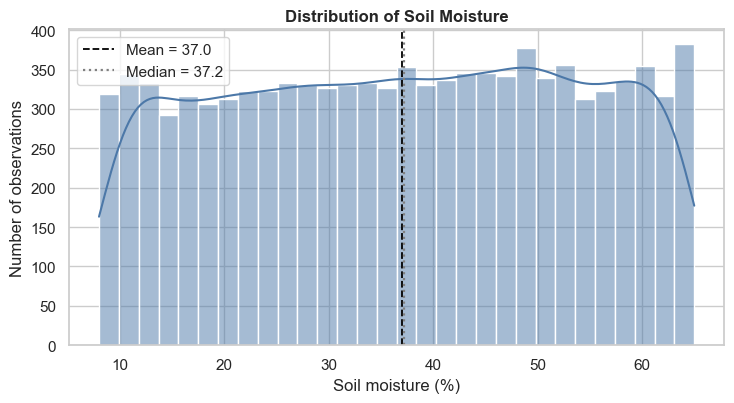

In [11]:
FEATURE_LABELS = {
    SOIL_COL: "Soil moisture (%)",
    TEMP_COL: "Temperature (°C)",
    HUM_COL: "Relative humidity (%)",
}
FEATURE_TITLES = {SOIL_COL: "Soil Moisture", TEMP_COL: "Temperature", HUM_COL: "Humidity"}
CLASS_COLORS = {"Low": "#4C9F70", "Medium": "#E9A23B", "High": "#C8443A"}

def plot_distribution(col, color):
    """Histogram + KDE + mean/median markers for one sensor variable."""
    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    sns.histplot(df[col], bins=30, kde=True, color=color, ax=ax)
    ax.axvline(df[col].mean(), color="black", ls="--", lw=1.3, label=f"Mean = {df[col].mean():.1f}")
    ax.axvline(df[col].median(), color="grey", ls=":", lw=1.6, label=f"Median = {df[col].median():.1f}")
    ax.set_title(f"Distribution of {FEATURE_TITLES[col]}")
    ax.set_xlabel(FEATURE_LABELS[col]); ax.set_ylabel("Number of observations")
    ax.legend(); plt.tight_layout(); plt.show()

plot_distribution(SOIL_COL, "#4C78A8")

**Interpretation.** Soil moisture is spread almost **evenly** between 8 % and 65 % (mean ≈ 37 %, median ≈ 37 %), rather than bell-shaped. The histogram bars are roughly the same height, and there is no cluster of extreme values.

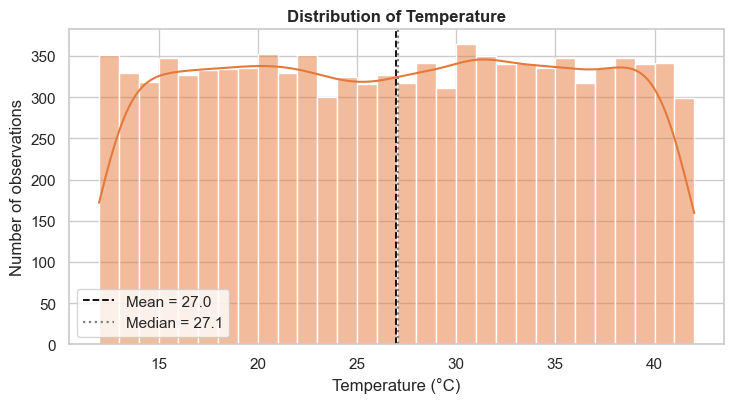

In [12]:
plot_distribution(TEMP_COL, "#E4793B")

**Interpretation.** Temperature is also spread roughly **evenly** between 12 °C and 42 °C (mean ≈ 27 °C, median ≈ 27 °C). No unusual spikes or gaps are visible.

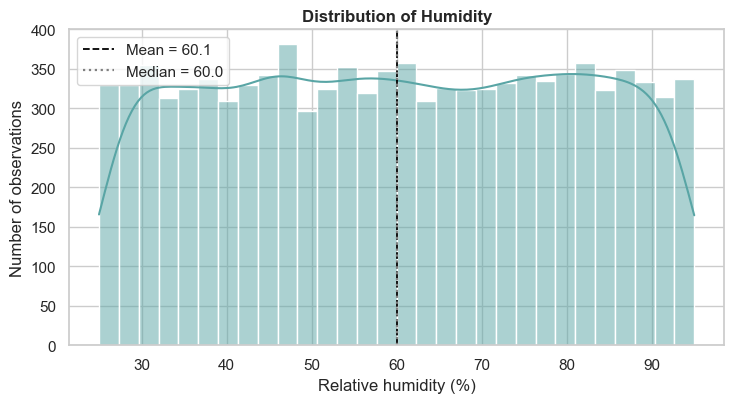

In [13]:
plot_distribution(HUM_COL, "#59A5A5")

**Interpretation.** Humidity is roughly **evenly** distributed between 25 % and 95 % (mean ≈ 60 %). All three sensor variables therefore cover their full range with similar density, which is convenient for training but unlike most real measurements, which usually cluster.

In [14]:
# Are the distributions flat? Compare counts in 10 equal-width bins.
flat = {c: np.histogram(df[c], bins=10)[0] for c in FEATURES}
for c, counts in flat.items():
    print(f"{c:14s} bin counts: {counts.tolist()}  (max/min = {counts.max()/counts.min():.2f})")
print()
print("Pairwise correlation between the three sensor variables:")
display(df[FEATURES].corr().round(3))

Soil_Moisture  bin counts: [997, 914, 958, 991, 990, 1020, 1034, 1072, 974, 1050]  (max/min = 1.17)
Temperature_C  bin counts: [998, 1007, 1021, 980, 968, 969, 1054, 1024, 999, 980]  (max/min = 1.09)
Humidity       bin counts: [1015, 974, 982, 1003, 1020, 992, 979, 1021, 1029, 985]  (max/min = 1.06)

Pairwise correlation between the three sensor variables:


,Soil_Moisture,Temperature_C,Humidity
Soil_Moisture,1.000,-0.005,0.007
Temperature_C,-0.005,1.000,-0.009
Humidity,0.007,-0.009,1.000


**Interpretation.** In 10 equal-width bins the largest bin is only 1.06–1.17 times the smallest, confirming near-uniform distributions. The three sensors are also essentially **uncorrelated** with each other (all |r| < 0.01), whereas in real fields temperature and humidity are normally related. This supports the note in Step 5 that the data looks simulated.

### 6.4 Correlation heatmap

The target is ordinal (Low < Medium < High), so it is encoded as 0/1/2 **only for this correlation plot** and Spearman (rank) correlation is used.

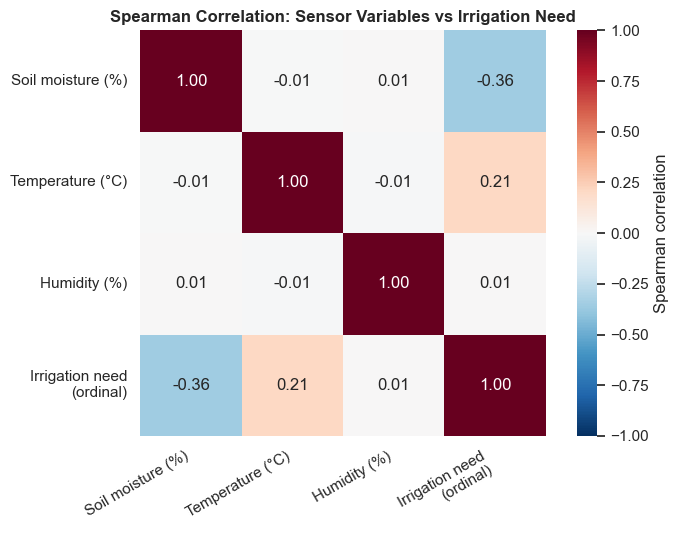

In [15]:
TARGET_ORDINAL = {label: i for i, label in enumerate(CLASS_ORDER)}   # Low=0, Medium=1, High=2
corr_frame = df[FEATURES].copy()
corr_frame["Irrigation_Need (Low=0, Med=1, High=2)"] = df[TARGET_COL].map(TARGET_ORDINAL)
corr = corr_frame.corr(method="spearman")

fig, ax = plt.subplots(figsize=(7.5, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, square=True, ax=ax,
            cbar_kws={"label": "Spearman correlation"})
ax.set_title("Spearman Correlation: Sensor Variables vs Irrigation Need")
ax.set_xticklabels(["Soil moisture (%)", "Temperature (°C)", "Humidity (%)", "Irrigation need\n(ordinal)"], rotation=30, ha="right")
ax.set_yticklabels(["Soil moisture (%)", "Temperature (°C)", "Humidity (%)", "Irrigation need\n(ordinal)"], rotation=0)
plt.tight_layout(); plt.show()

**Interpretation.** Spearman correlations with the ordinal irrigation need are:
* **Soil moisture: −0.36** – drier soil goes with higher irrigation need (the strongest of the three).
* **Temperature: +0.21** – hotter conditions go with higher need.
* **Humidity: ≈ 0.00** – no monotonic relationship with irrigation need in this dataset.

The correlations are moderate at best, so no single sensor determines the class on its own. Correlation does not show causation.

### 6.5 Feature relationships with the irrigation requirement

Because the target has three categories, a plain scatter plot would place all points on three horizontal lines. To make the relationship readable:

1. **Jittered scatter plots** – each point is one observation, with small random vertical jitter so points do not overlap; the black diamonds are the class averages.
2. **Box plots** – show the spread of each sensor value within each class.
3. **Class share by value range** – for each range of a sensor value, what fraction of observations are Low / Medium / High.


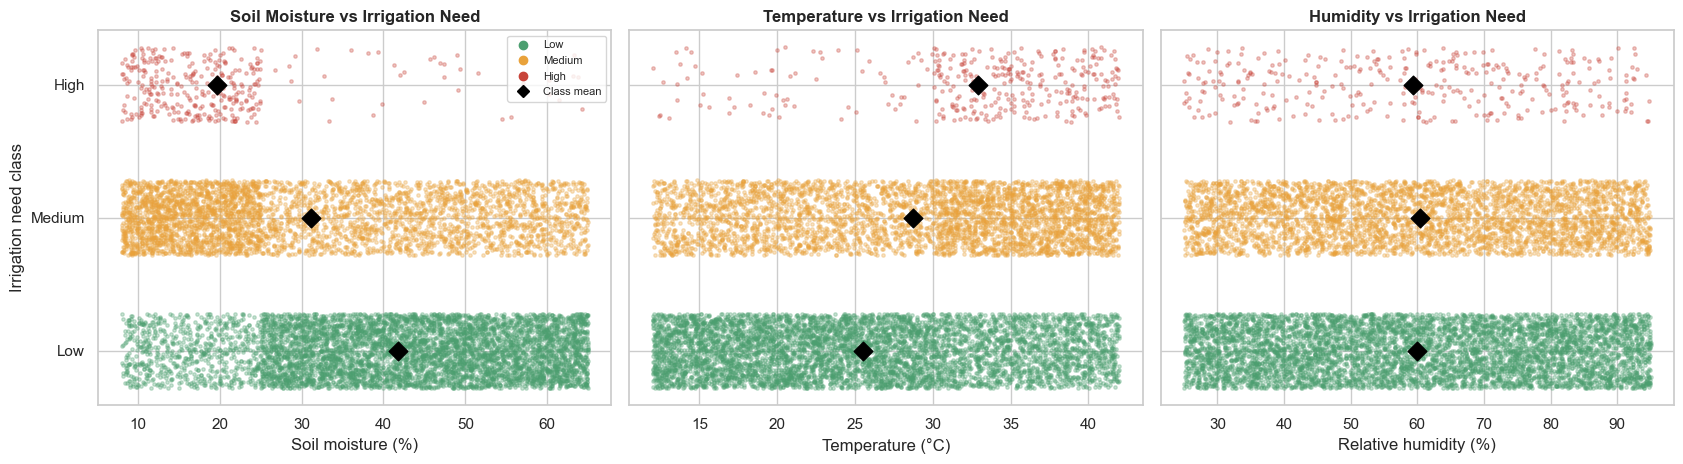

In [16]:
rng = np.random.default_rng(RANDOM_STATE)
y_num = df[TARGET_COL].map(TARGET_ORDINAL)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True)
for ax, col in zip(axes, FEATURES):
    for label in CLASS_ORDER:
        mask = df[TARGET_COL] == label
        ax.scatter(df.loc[mask, col], y_num[mask] + rng.uniform(-0.28, 0.28, mask.sum()),
                   s=6, alpha=0.30, color=CLASS_COLORS[label], label=label)
    means = df.groupby(TARGET_COL)[col].mean().reindex(CLASS_ORDER)
    ax.scatter(means.values, range(3), marker="D", s=90, color="black", zorder=5, label="Class mean")
    ax.set_title(f"{FEATURE_TITLES[col]} vs Irrigation Need")
    ax.set_xlabel(FEATURE_LABELS[col])
axes[0].set_ylabel("Irrigation need class")
axes[0].set_yticks(range(3)); axes[0].set_yticklabels(CLASS_ORDER)
from matplotlib.lines import Line2D
handles = [Line2D([], [], marker="o", ls="", color=CLASS_COLORS[c], label=c) for c in CLASS_ORDER] +           [Line2D([], [], marker="D", ls="", color="black", label="Class mean")]
axes[0].legend(handles=handles, loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

**Interpretation.**
* **Soil moisture:** almost all *High* points lie below ≈ 25 %, and *Low* points become much denser above ≈ 25 %. There is a visible **threshold** near 25 %.
* **Temperature:** *High* points are concentrated above ≈ 30 °C.
* **Humidity:** all three classes are spread across the whole humidity range; the class averages (diamonds) sit at almost the same humidity.

The classes overlap heavily, especially *Medium* with the others, so three sensors alone will not separate them cleanly.

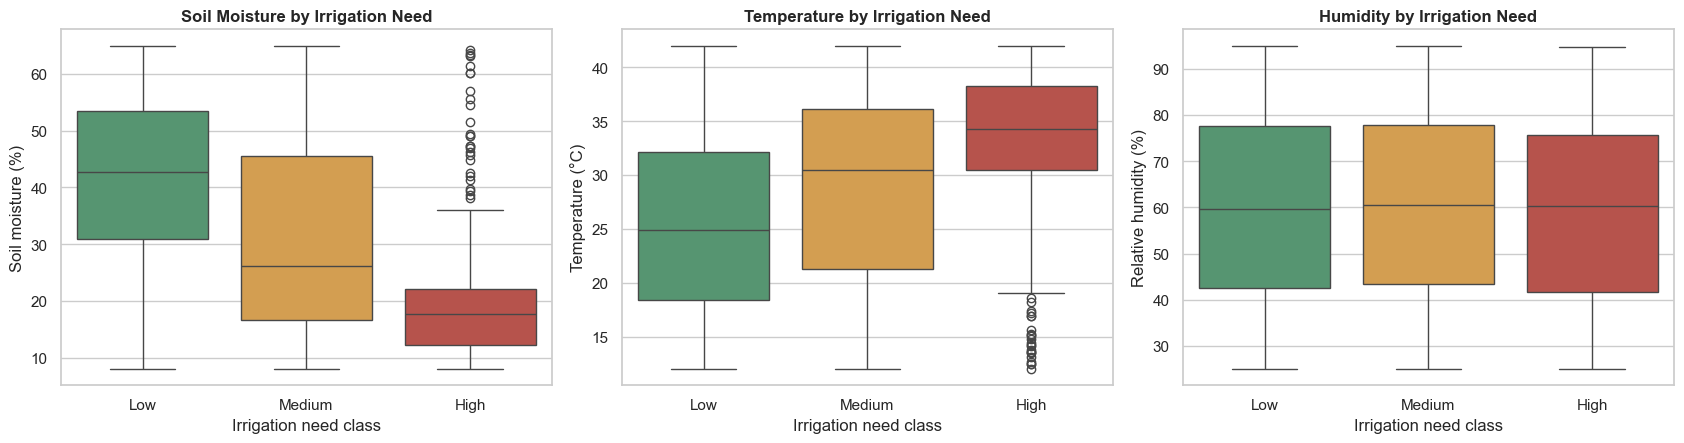

Mean of each sensor variable per class:


Soil_Moisture        Temperature_C       Humidity       
                         mean    std          mean   std     mean    std
Irrigation_Need                                                         
Low                     41.72  14.44         25.54  8.41    59.97  20.26
Medium                  31.16  16.83         28.71  8.64    60.32  20.09
High                    19.71  10.84         32.88  7.18    59.31  20.07

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
for ax, col in zip(axes, FEATURES):
    sns.boxplot(data=df, x=TARGET_COL, y=col, order=CLASS_ORDER, palette=CLASS_COLORS, ax=ax)
    ax.set_title(f"{FEATURE_TITLES[col]} by Irrigation Need")
    ax.set_xlabel("Irrigation need class"); ax.set_ylabel(FEATURE_LABELS[col])
plt.tight_layout(); plt.show()

print("Mean of each sensor variable per class:")
display(df.groupby(TARGET_COL)[FEATURES].agg(["mean", "std"]).reindex(CLASS_ORDER).round(2))

**Interpretation.** Median soil moisture falls from ≈ 43 % (Low) to ≈ 26 % (Medium) to ≈ 18 % (High), and median temperature rises from ≈ 25 °C to ≈ 30 °C to ≈ 34 °C. Humidity medians are almost identical in all three classes (≈ 60 %). The boxes for Low and Medium overlap substantially, which limits how well any model can separate them from these inputs.

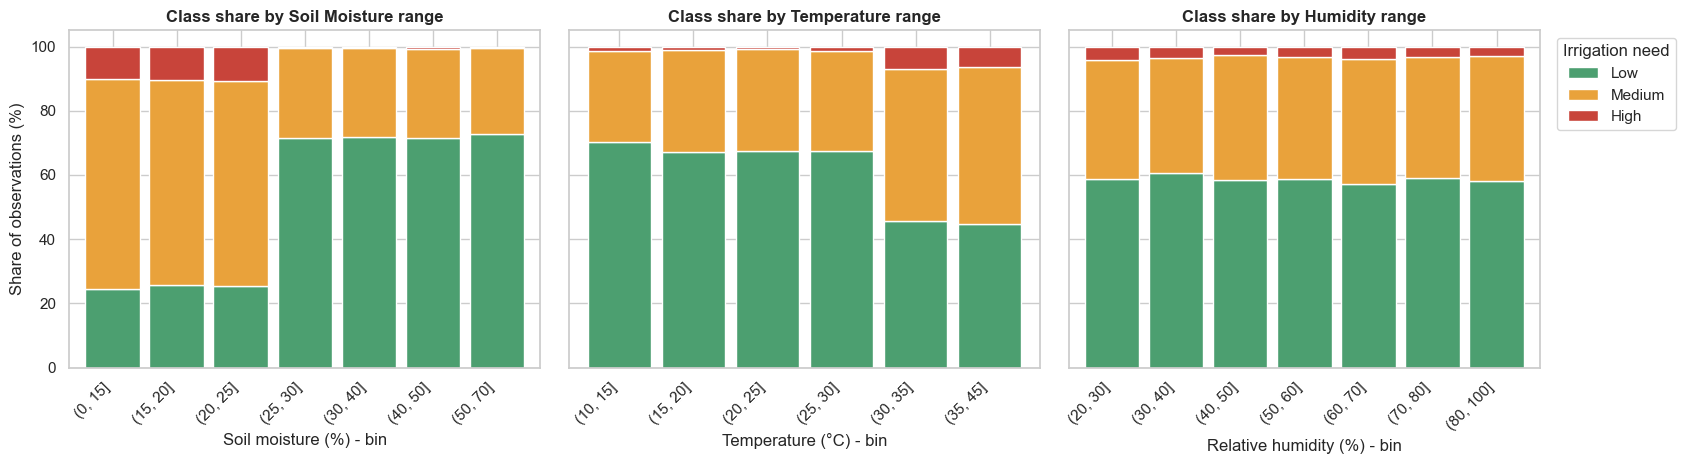

In [18]:
bin_edges = {SOIL_COL: [0, 15, 20, 25, 30, 40, 50, 70],
             TEMP_COL: [10, 15, 20, 25, 30, 35, 45],
             HUM_COL:  [20, 30, 40, 50, 60, 70, 80, 100]}

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True)
for ax, col in zip(axes, FEATURES):
    bins = pd.cut(df[col], bins=bin_edges[col])
    share = pd.crosstab(bins, df[TARGET_COL], normalize="index")[CLASS_ORDER] * 100
    share.plot(kind="bar", stacked=True, ax=ax, color=[CLASS_COLORS[c] for c in CLASS_ORDER], width=0.85, legend=False)
    ax.set_title(f"Class share by {FEATURE_TITLES[col]} range")
    ax.set_xlabel(FEATURE_LABELS[col] + " - bin"); ax.set_xticklabels([str(i) for i in share.index], rotation=45, ha="right")
axes[0].set_ylabel("Share of observations (%)")
axes[-1].legend(CLASS_ORDER, title="Irrigation need", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

**Interpretation.**
* **Soil moisture:** below 25 %, about 64–65 % of observations are *Medium* and 10–11 % are *High*; above 25 %, about 71–73 % are *Low* and *High* almost disappears (≈ 0–1 %). The change happens sharply at about 25 %.
* **Temperature:** up to 30 °C, *High* is only ≈ 1 %; above 30 °C it rises to ≈ 6–7 % and *Low* drops from ≈ 67–70 % to ≈ 45 %.
* **Humidity:** the class shares stay nearly constant (Low ≈ 58–60 %, High ≈ 3–4 %) in every range – humidity carries little information about the target here.

## Step 7 — Geographic Visualization / Map

The dataset is searched for latitude/longitude or other location fields before deciding whether a map is possible.


In [19]:
geo_keywords = ["lat", "lon", "lng", "long", "gps", "coord", "location", "region", "city", "country", "farm", "district", "state"]
geo_cols = [c for c in df_raw.columns if any(k in c.lower() for k in geo_keywords)]
lat_cols = [c for c in df_raw.columns if c.lower() in ("lat", "latitude")]
lon_cols = [c for c in df_raw.columns if c.lower() in ("lon", "lng", "long", "longitude")]

print("Possible geographic columns:", geo_cols)
print("Latitude columns :", lat_cols, "| Longitude columns:", lon_cols)
HAS_COORDINATES = bool(lat_cols and lon_cols)
print("Coordinates available:", HAS_COORDINATES)
for c in geo_cols:
    print(f"  {c}: {df_raw[c].value_counts().to_dict()}")

Possible geographic columns: ['Region']
Latitude columns : [] | Longitude columns: []
Coordinates available: False
  Region: {'South': 2102, 'West': 2017, 'East': 1994, 'Central': 1987, 'North': 1900}


> **The dataset does not contain geographic coordinates, so a meaningful observation-level map cannot be generated from this dataset.**

It does contain a coarse categorical `Region` column (North / South / East / West / Central) but no shapes, names of real places or GPS points, so no coordinates are invented. As the closest honest alternative, the chart below summarises irrigation need **by region** (a bar chart, not a map). `Region` is **not** used as a model feature.

**How location could be added in the IoT deployment:** each field node could carry a GPS module (or a fixed, surveyed latitude/longitude stored in the node's configuration) and send it along with each reading. With coordinates and real sensor data, a `folium` map of fields coloured by predicted irrigation need would be straightforward, and location could later support weather-forecast look-ups.


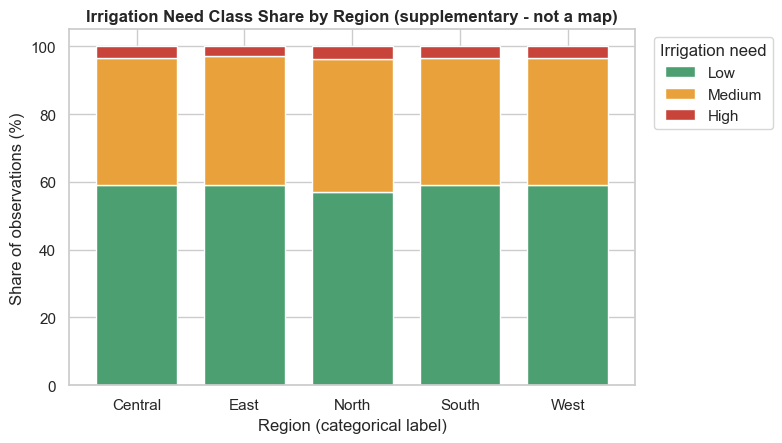

Irrigation_Need,Low,Medium,High
Region,,,
Central,59.0,37.4,3.5
East,59.1,38.2,2.7
North,57.1,39.3,3.6
South,58.9,37.5,3.5
West,59.0,37.6,3.4


In [20]:
region_share = pd.crosstab(df["Region"], df[TARGET_COL], normalize="index")[CLASS_ORDER] * 100
ax = region_share.plot(kind="bar", stacked=True, figsize=(8, 4.6), color=[CLASS_COLORS[c] for c in CLASS_ORDER], width=0.75)
ax.set_title("Irrigation Need Class Share by Region (supplementary - not a map)")
ax.set_xlabel("Region (categorical label)"); ax.set_ylabel("Share of observations (%)")
ax.legend(title="Irrigation need", bbox_to_anchor=(1.02, 1), loc="upper left"); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()
display(region_share.round(1))

**Interpretation.** Class shares are nearly the same in all five regions (Low ≈ 57–59 %, Medium ≈ 37–39 %, High ≈ 2.7–3.6 %), so `Region` shows no meaningful difference in irrigation need here.

## Step 8 — Define Features and Target

* **`X`** – the *input matrix*: one row per observation, three columns (soil moisture, temperature, humidity). This is what the physical sensors will supply.
* **`y`** – the *target vector*: the irrigation-need label the model must learn to predict. It is the dataset's own `Irrigation_Need` column with the classes **Low, Medium, High**.

**Why these three inputs?** They are the measurements that a low-cost IoT node can realistically provide (a capacitive soil-moisture probe and a DHT-type temperature/humidity sensor), which is the constraint of the final system. Other columns in the dataset (crop type, growth stage, region, rainfall, soil pH …) would need extra data entry, weather feeds or laboratory tests, so they are intentionally excluded.


### Original dataset target vs derived pump decision

Two different things are used in this project and must not be confused:

| | **Original dataset target** | **Derived pump decision** |
|---|---|---|
| Column / name | `Irrigation_Need` | `IRRIGATION_POLICY` applied to a prediction |
| Values | **Low, Medium, High** | Irrigation Not Needed / Irrigation Needed |
| Source | Supplied in the dataset | **Assumption made in this project** |
| Used for | Training, tuning and evaluating the model | Turning a prediction into a pump recommendation |

**Assumption (not from the dataset):** *Low → Not Needed*; *Medium and High → Needed*. The dataset does not state which levels should start the pump, so this rule must be confirmed with an agronomist and can be edited in one place (`IRRIGATION_POLICY`, Step 14.1). The model itself is always trained on the original three classes.

**Model inputs.** Only the three sensor features (`Soil_Moisture`, `Temperature_C`, `Humidity`) are used by the project model. The one exception is the clearly labelled diagnostic in Step 15.1, which trains a separate reference model on all columns purely to measure what the three-sensor restriction costs; it is never used for selection, prediction or deployment.


In [21]:
X = df[FEATURES].copy()
y = df[TARGET_COL].copy()
print("X shape:", X.shape, "| y shape:", y.shape)
print("Feature order:", list(X.columns))
display(X.head(3))
print("Target classes:", CLASS_ORDER, "(Low = little/no irrigation needed, High = urgent irrigation need)")

X shape: (10000, 3) | y shape: (10000,)
Feature order: ['Soil_Moisture', 'Temperature_C', 'Humidity']


,Soil_Moisture,Temperature_C,Humidity
0,36.48,21.90,31.19
1,50.56,36.50,26.01
2,40.07,41.83,76.41


Target classes: ['Low', 'Medium', 'High'] (Low = little/no irrigation needed, High = urgent irrigation need)


## Step 9 — Check Target Distribution

,count,percent
Irrigation_Need,,
Low,5864,58.64
Medium,3800,38.00
High,336,3.36


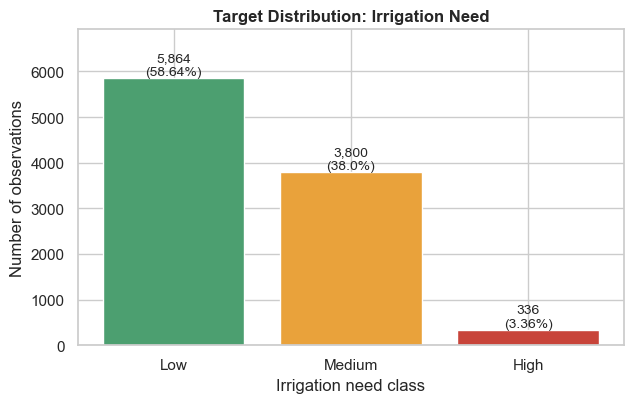

Imbalance ratio (largest / smallest class): 17.5 : 1


In [22]:
class_counts = y.value_counts().reindex(CLASS_ORDER)
class_pct = (class_counts / class_counts.sum() * 100).round(2)
display(pd.DataFrame({"count": class_counts, "percent": class_pct}))

fig, ax = plt.subplots(figsize=(6.5, 4.2))
bars = ax.bar(CLASS_ORDER, class_counts.values, color=[CLASS_COLORS[c] for c in CLASS_ORDER])
for bar, pct in zip(bars, class_pct):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 60, f"{int(bar.get_height()):,}\n({pct}%)", ha="center", fontsize=10)
ax.set_title("Target Distribution: Irrigation Need"); ax.set_xlabel("Irrigation need class")
ax.set_ylabel("Number of observations"); ax.set_ylim(0, class_counts.max() * 1.18)
plt.tight_layout(); plt.show()
print(f"Imbalance ratio (largest / smallest class): {class_counts.max() / class_counts.min():.1f} : 1")

**Interpretation.** The dataset is **not balanced**: *Low* is 58.6 %, *Medium* 38.0 % and *High* only 3.4 % (336 rows; 67 in the test set), a ratio of about 17.5 : 1.

**Effect on evaluation.** A model that always answers "Low" would already reach ≈ 58.6 % accuracy, so **accuracy alone is misleading**. Accuracy can look acceptable while the rare *High* class – the one where under-irrigation is most damaging – is never detected. Per-class recall, precision and macro-averaged scores are therefore reported. Because rows were not resampled, the test set keeps the real class proportions. Instead of oversampling/undersampling, the `class_weight="balanced"` option is tested as a lighter-touch remedy (Step 12), since missing *High* cases matters for this application.

## Step 10 — Prepare the Data (Train / Test Split)

The data is split into a **training set** (80 %), used to fit and tune the models, and a **test set** (20 %), which stays **unseen** until the final evaluation. The test set mimics future, never-seen sensor readings: if the model were evaluated on the data it learned from, accuracy would be overly optimistic and we could not detect overfitting.

`stratify=y` keeps the Low/Medium/High proportions identical in both parts — essential here because the *High* class is rare.


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

print(f"Training set: {X_train.shape[0]:,} rows | Test set: {X_test.shape[0]:,} rows")
split_check = pd.DataFrame({
    "train_%": (y_train.value_counts(normalize=True).reindex(CLASS_ORDER) * 100).round(2),
    "test_%":  (y_test.value_counts(normalize=True).reindex(CLASS_ORDER) * 100).round(2),
    "train_n": y_train.value_counts().reindex(CLASS_ORDER),
    "test_n":  y_test.value_counts().reindex(CLASS_ORDER)})
display(split_check)

Training set: 8,000 rows | Test set: 2,000 rows


,train_%,test_%,train_n,test_n
Irrigation_Need,,,,
Low,58.64,58.65,4691,1173
Medium,38.00,38.00,3040,760
High,3.36,3.35,269,67


## Step 11 — Feature Scaling

**What scaling does.** `StandardScaler` transforms each feature to mean 0 and standard deviation 1 (`z = (x − mean) / std`), so soil moisture (8–65), temperature (12–42) and humidity (25–95) are on comparable scales.

**Is it necessary?** It depends on the model:

| Model | Needs scaling? | Why |
|---|---|---|
| Logistic Regression | **Yes (helps)** | Uses gradient-based optimisation and regularisation, both sensitive to feature scale; also makes coefficients comparable. |
| Decision Tree / Random Forest | No | Splits are threshold comparisons on a single feature; monotonic rescaling does not change them. |

**Avoiding data leakage.** The scaler's mean and standard deviation must be learned from the **training data only**. If they were computed on the full dataset, information about the test set would leak into training. Wrapping scaler + model in a scikit-learn **`Pipeline`** guarantees this: the scaler is fitted on the training part only (including inside each cross-validation fold) and re-applied unchanged to any new data. Tree models use `"passthrough"` in the scaler slot so every candidate has the same pipeline structure.


In [39]:
def build_pipeline(model, scale):
    """Scaler (or passthrough) + model in one object -> no leakage, one object to deploy."""
    return Pipeline([("scaler", StandardScaler() if scale else "passthrough"),
                     ("clf", model)])

# Quick demonstration that the scaler learns from the training data only
demo_scaler = StandardScaler().fit(X_train)
print("Scaler means learned from TRAINING data:", dict(zip(FEATURES, demo_scaler.mean_.round(2))))
print("Scaler std devs learned from TRAINING data:", dict(zip(FEATURES, demo_scaler.scale_.round(2))))

Scaler means learned from TRAINING data: {'Soil_Moisture': 37.14, 'Temperature_C': 27.02, 'Humidity': 60.24}
Scaler std devs learned from TRAINING data: {'Soil_Moisture': 16.45, 'Temperature_C': 8.63, 'Humidity': 20.14}


## Step 12 — Train Multiple Candidate Models

Three model families are compared. This is a small tabular problem (3 features, 10,000 rows), so deep learning would be unjustified.

* **Logistic Regression** – a simple, fast, interpretable baseline. It learns a weighted sum of the scaled sensor values and converts it to class probabilities. It can only draw *linear* class boundaries.
* **Decision Tree** – learns a set of `if soil_moisture < x …` rules from the sensor values. Easy to read and to run on a microcontroller, but a deep tree can overfit.
* **Random Forest** – averages many decision trees trained on random subsets of the data. Captures non-linear relationships and is usually more stable than one tree, but is larger and harder to explain.

**Handling the imbalanced *High* class.** *High* is only a few percent of the data (Step 9). Each family is therefore trained twice: normally, and with `class_weight="balanced"`, which penalises mistakes on rare classes more heavily. This changes the model, not the data (no oversampling / undersampling).

**Tuning without touching the test set.** Hyper-parameters are chosen with 5-fold stratified cross-validation on the **training set only**, using **macro-F1** (the average F1 of the three classes, so the rare *High* class counts as much as the common *Low* class) as the tuning score.


In [40]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

candidate_specs = {
    "Logistic Regression": dict(
        pipe=build_pipeline(LogisticRegression(max_iter=2000, random_state=RANDOM_STATE), scale=True),
        grid={"clf__C": [0.01, 0.1, 1, 10, 100]}),
    "Logistic Regression (balanced)": dict(
        pipe=build_pipeline(LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE), scale=True),
        grid={"clf__C": [0.01, 0.1, 1, 10, 100]}),
    "Decision Tree": dict(
        pipe=build_pipeline(DecisionTreeClassifier(random_state=RANDOM_STATE), scale=False),
        grid={"clf__max_depth": [2, 3, 4, 5, 6, 8, 10], "clf__min_samples_leaf": [5, 20, 50]}),
    "Decision Tree (balanced)": dict(
        pipe=build_pipeline(DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE), scale=False),
        grid={"clf__max_depth": [2, 3, 4, 5, 6, 8, 10], "clf__min_samples_leaf": [5, 20, 50]}),
    "Random Forest": dict(
        pipe=build_pipeline(RandomForestClassifier(n_estimators=150, random_state=RANDOM_STATE, n_jobs=1), scale=False),
        grid={"clf__max_depth": [4, 6, 8], "clf__min_samples_leaf": [10, 30], "clf__max_features": [1, 2]}),
    "Random Forest (balanced)": dict(
        pipe=build_pipeline(RandomForestClassifier(n_estimators=150, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=1), scale=False),
        grid={"clf__max_depth": [4, 6, 8], "clf__min_samples_leaf": [10, 30], "clf__max_features": [1, 2]}),
}

fitted_models, best_params = {}, {}
for name, spec in candidate_specs.items():
    search = GridSearchCV(spec["pipe"], spec["grid"], scoring="f1_macro", cv=cv, n_jobs=1, refit=True)
    search.fit(X_train, y_train)                       # TRAINING DATA ONLY
    fitted_models[name] = search.best_estimator_
    best_params[name] = {k.replace("clf__", ""): v for k, v in search.best_params_.items()}
    print(f"{name:34s} best CV macro-F1 = {search.best_score_:.4f}  params = {best_params[name]}")

Logistic Regression                best CV macro-F1 = 0.4320  params = {'C': 0.1}
Logistic Regression (balanced)     best CV macro-F1 = 0.4315  params = {'C': 1}
Decision Tree                      best CV macro-F1 = 0.4639  params = {'max_depth': 4, 'min_samples_leaf': 5}
Decision Tree (balanced)           best CV macro-F1 = 0.5114  params = {'max_depth': 2, 'min_samples_leaf': 5}
Random Forest                      best CV macro-F1 = 0.4492  params = {'max_depth': 8, 'max_features': 2, 'min_samples_leaf': 30}
Random Forest (balanced)           best CV macro-F1 = 0.5095  params = {'max_depth': 6, 'max_features': 1, 'min_samples_leaf': 10}


Decision Tree (balanced)           best CV macro-F1 = 0.5114  params = {'max_depth': 2, 'min_samples_leaf': 5}


Random Forest                      best CV macro-F1 = 0.4492  params = {'max_depth': 8, 'max_features': 2, 'min_samples_leaf': 30}


Random Forest (balanced)           best CV macro-F1 = 0.5095  params = {'max_depth': 6, 'max_features': 1, 'min_samples_leaf': 10}


## Step 13 — Evaluate the Models

**Metrics** (computed on the unseen test set):

* **Accuracy** – share of all predictions that are correct. Can hide poor performance on a rare class.
* **Precision** – of the observations predicted as a class, how many truly belong to it.
* **Recall** – of the observations that truly belong to a class, how many the model found.
* **F1-score** – harmonic mean of precision and recall.
* **Macro** averages weight the three classes equally.

**Why recall matters most for irrigation.** A missed genuine irrigation requirement (a false negative) means the crop is **under-irrigated**: the model says “Low/Medium” when the field really needs “High”. This is the costlier error for crop health. A false alarm (unnecessary irrigation) mainly wastes water and energy. Recall of the **High** class is therefore examined closely, but never in isolation, because a model that predicts “High” for everything would have perfect High-recall and be useless.


In [41]:
def summarize(y_true, y_pred):
    """Overall + per-class metrics for the 3-class problem."""
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, labels=CLASS_ORDER, zero_division=0)
    out = {"accuracy": accuracy_score(y_true, y_pred),
           "macro_precision": p.mean(), "macro_recall": r.mean(), "macro_f1": f.mean()}
    for i, label in enumerate(CLASS_ORDER):
        out[f"precision_{label}"], out[f"recall_{label}"], out[f"f1_{label}"] = p[i], r[i], f[i]
    return out

test_predictions = {name: model.predict(X_test) for name, model in fitted_models.items()}
test_results = pd.DataFrame({name: summarize(y_test, pred) for name, pred in test_predictions.items()}).T
display(test_results[["accuracy", "macro_precision", "macro_recall", "macro_f1",
                      "precision_High", "recall_High", "f1_High"]].round(3))

,accuracy,macro_precision,macro_recall,macro_f1,precision_High,recall_High,f1_High
Logistic Regression,0.662,0.426,0.434,0.428,0.000,0.000,0.000
Logistic Regression (balanced),0.512,0.421,0.551,0.407,0.109,0.716,0.190
Decision Tree,0.695,0.519,0.457,0.455,0.200,0.015,0.028
Decision Tree (balanced),0.578,0.484,0.595,0.489,0.177,0.642,0.277
Random Forest,0.698,0.453,0.456,0.450,0.000,0.000,0.000
Random Forest (balanced),0.590,0.477,0.589,0.489,0.174,0.627,0.272


In [42]:
print("Per-class precision / recall / F1 on the test set")
per_class = test_results[[f"{m}_{c}" for c in CLASS_ORDER for m in ("precision", "recall", "f1")]].round(3)
per_class.columns = pd.MultiIndex.from_product([CLASS_ORDER, ["precision", "recall", "f1"]])
display(per_class)

Per-class precision / recall / F1 on the test set


Low                  Medium                    High              
                               precision recall     f1 precision recall     f1 precision recall     f1
Logistic Regression                0.704  0.808  0.753     0.573  0.493  0.530     0.000  0.000  0.000
Logistic Regression (balanced)     0.747  0.641  0.690     0.406  0.296  0.342     0.109  0.716  0.190
Decision Tree                      0.721  0.870  0.788     0.637  0.484  0.550     0.200  0.015  0.028
Decision Tree (balanced)           0.807  0.591  0.682     0.468  0.553  0.507     0.177  0.642  0.277
Random Forest                      0.725  0.863  0.788     0.635  0.505  0.563     0.000  0.000  0.000
Random Forest (balanced)           0.778  0.655  0.711     0.480  0.487  0.483     0.174  0.627  0.272

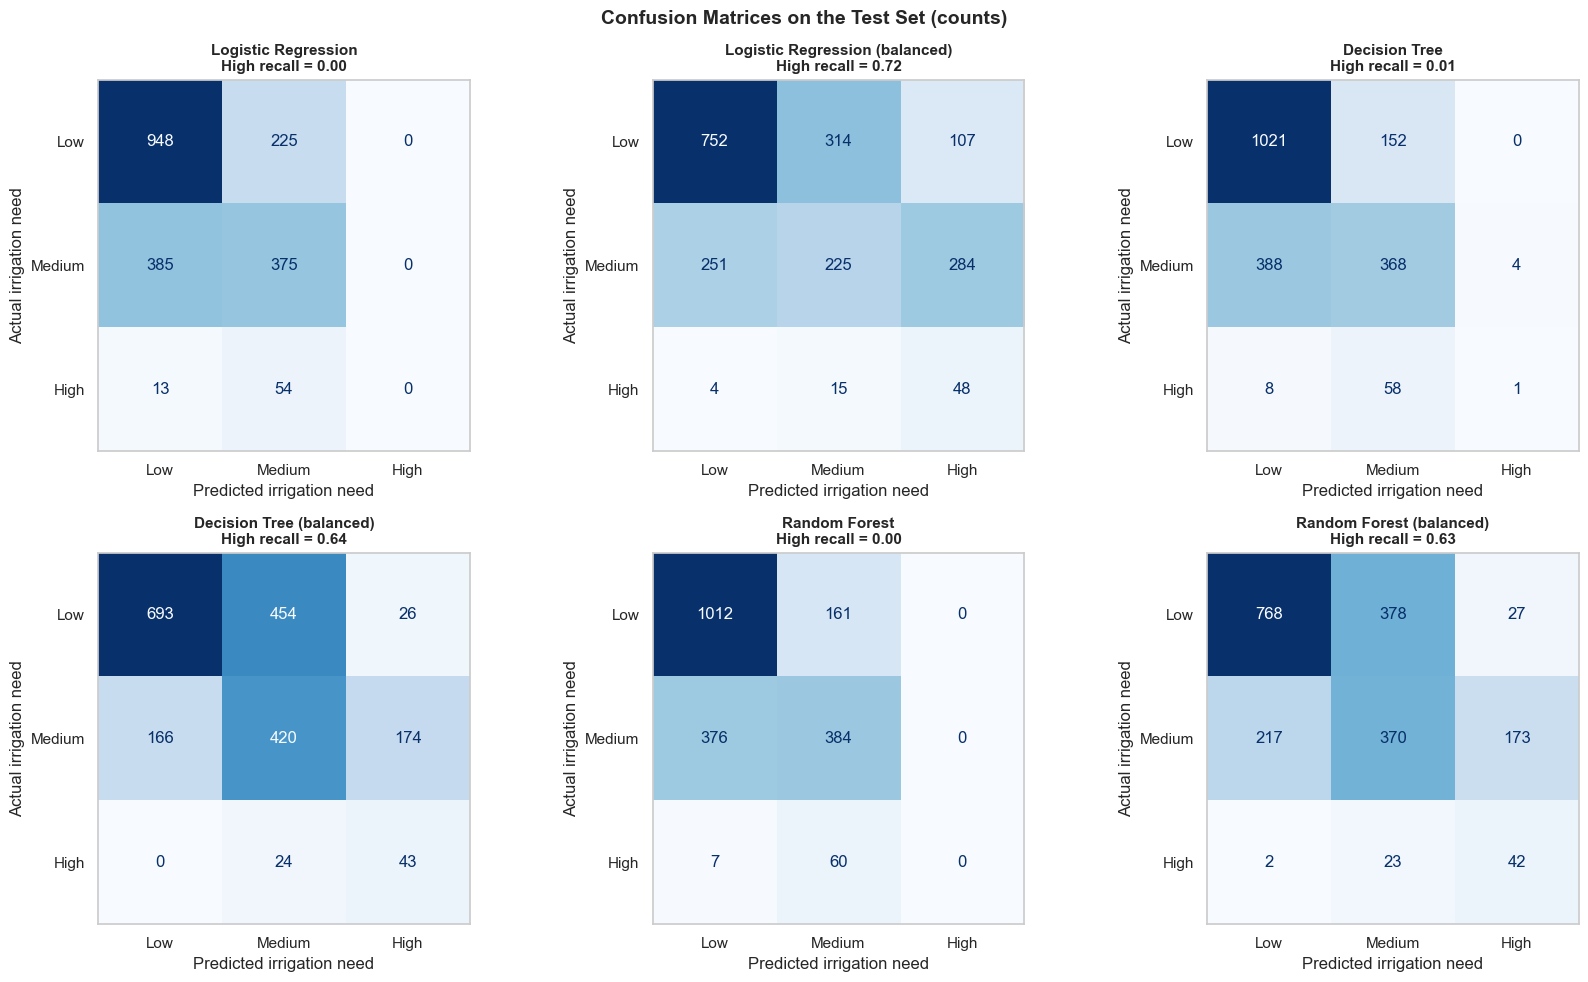

In [43]:
# Confusion matrices for all candidates (rows = actual, columns = predicted)
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
for ax, (name, pred) in zip(axes.ravel(), test_predictions.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, pred, labels=CLASS_ORDER, cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(f"{name}\nHigh recall = {test_results.loc[name, 'recall_High']:.2f}", fontsize=11)
    ax.set_xlabel("Predicted irrigation need"); ax.set_ylabel("Actual irrigation need"); ax.grid(False)
plt.suptitle("Confusion Matrices on the Test Set (counts)", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

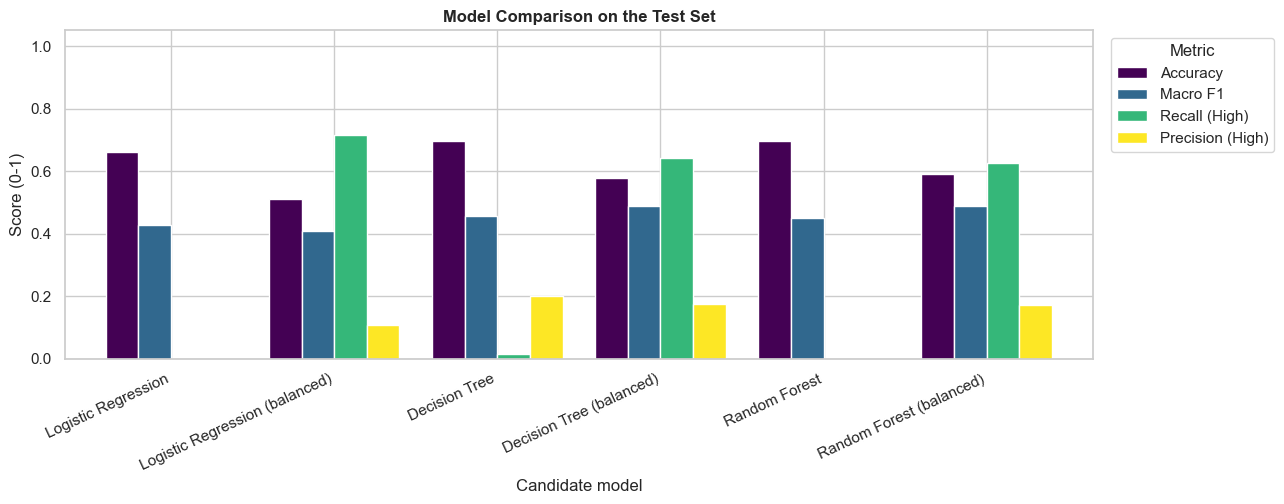

In [44]:
# Model comparison chart
plot_cols = {"accuracy": "Accuracy", "macro_f1": "Macro F1", "recall_High": "Recall (High)", "precision_High": "Precision (High)"}
comparison = test_results[list(plot_cols)].rename(columns=plot_cols)
ax = comparison.plot(kind="bar", figsize=(13, 5.2), width=0.8, colormap="viridis")
ax.set_title("Model Comparison on the Test Set"); ax.set_xlabel("Candidate model"); ax.set_ylabel("Score (0-1)")
ax.set_ylim(0, 1.05); plt.xticks(rotation=25, ha="right"); ax.legend(title="Metric", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout(); plt.show()

**Interpretation of the test-set results.**

* **Models without class weights** reach the highest accuracy (66–70 %), but they almost **never detect the High class**: recall for *High* is 0.00 for Logistic Regression and Random Forest, and 0.015 for the Decision Tree. Their accuracy is only slightly above the 58.7 % "always Low" baseline.
* **Models with `class_weight="balanced"`** find most *High* cases (recall 0.63–0.72), but at a cost: precision for *High* is only 0.11–0.18 (many false alarms), and overall accuracy falls to 51–59 %.
* Among the balanced models, the **Decision Tree and Random Forest are nearly equal** (macro-F1 0.489 vs 0.489; High recall 0.64 vs 0.63). Balanced Logistic Regression has the highest High recall (0.72) but the lowest macro-F1 and accuracy (0.407 and 0.51).
* No model performs strongly. The best macro-F1 is ≈ 0.49 on a 3-class task, which is a **modest** result. The reason is examined in Step 15.1.

This is a genuine trade-off between catching under-irrigation risk (recall) and avoiding unnecessary alerts (precision), not a problem with one model in particular.

## Step 14 — Select the Final Model

The final model is chosen **without looking at the test set**, using out-of-fold predictions on the **training set** (each training row is predicted by a model that did not see it). The test-set numbers above are only used afterwards, to confirm the choice.

**Selection rule (fixed before looking at the result):**
1. Keep every candidate whose cross-validated **macro-F1** is within **0.01** of the best one (differences that small are within noise).
2. Among those, choose the one with the highest cross-validated **recall for the High class** (under-irrigation risk).
3. If still tied, prefer the simpler / more interpretable model (Logistic Regression < Decision Tree < Random Forest).

Interpretability and deployment simplicity are then discussed in the text below the table.


In [45]:
cv_predictions = {name: cross_val_predict(model, X_train, y_train, cv=cv, n_jobs=1)
                  for name, model in fitted_models.items()}
cv_results = pd.DataFrame({name: summarize(y_train, pred) for name, pred in cv_predictions.items()}).T
cv_view = cv_results[["accuracy", "macro_f1", "precision_High", "recall_High", "f1_High", "recall_Medium", "recall_Low"]].round(3)
display(cv_view.sort_values("macro_f1", ascending=False))

# --- apply the pre-declared selection rule -----------------------------------
complexity_rank = {"Logistic Regression": 1, "Decision Tree": 2, "Random Forest": 3}
family = lambda n: n.replace(" (balanced)", "")
best_f1 = cv_results["macro_f1"].max()
shortlist = cv_results[cv_results["macro_f1"] >= best_f1 - 0.01].copy()
shortlist["complexity"] = [complexity_rank[family(n)] for n in shortlist.index]
shortlist = shortlist.sort_values(["recall_High", "complexity"], ascending=[False, True])
FINAL_NAME = shortlist.index[0]
final_pipeline = fitted_models[FINAL_NAME]

print("Shortlist (CV macro-F1 within 0.01 of the best):")
display(shortlist[["macro_f1", "recall_High", "complexity"]].round(3))
print(f"\nSELECTED FINAL MODEL: {FINAL_NAME}   |   parameters: {best_params[FINAL_NAME]}")

,accuracy,macro_f1,precision_High,recall_High,f1_High,recall_Medium,recall_Low
Decision Tree (balanced),0.596,0.511,0.200,0.699,0.311,0.584,0.598
Random Forest (balanced),0.604,0.510,0.195,0.695,0.305,0.516,0.656
Decision Tree,0.698,0.464,0.333,0.026,0.048,0.484,0.876
Random Forest,0.699,0.449,0.000,0.000,0.000,0.493,0.872
Logistic Regression,0.670,0.432,0.000,0.000,0.000,0.489,0.826
Logistic Regression (balanced),0.536,0.432,0.126,0.773,0.217,0.326,0.659


Shortlist (CV macro-F1 within 0.01 of the best):


,macro_f1,recall_High,complexity
Decision Tree (balanced),0.511,0.699,2
Random Forest (balanced),0.510,0.695,3



SELECTED FINAL MODEL: Decision Tree (balanced)   |   parameters: {'max_depth': 2, 'min_samples_leaf': 5}


Final model: Decision Tree (balanced)

              precision    recall  f1-score   support

         Low      0.807     0.591     0.682      1173
      Medium      0.468     0.553     0.507       760
        High      0.177     0.642     0.277        67

    accuracy                          0.578      2000
   macro avg      0.484     0.595     0.489      2000
weighted avg      0.657     0.578     0.602      2000



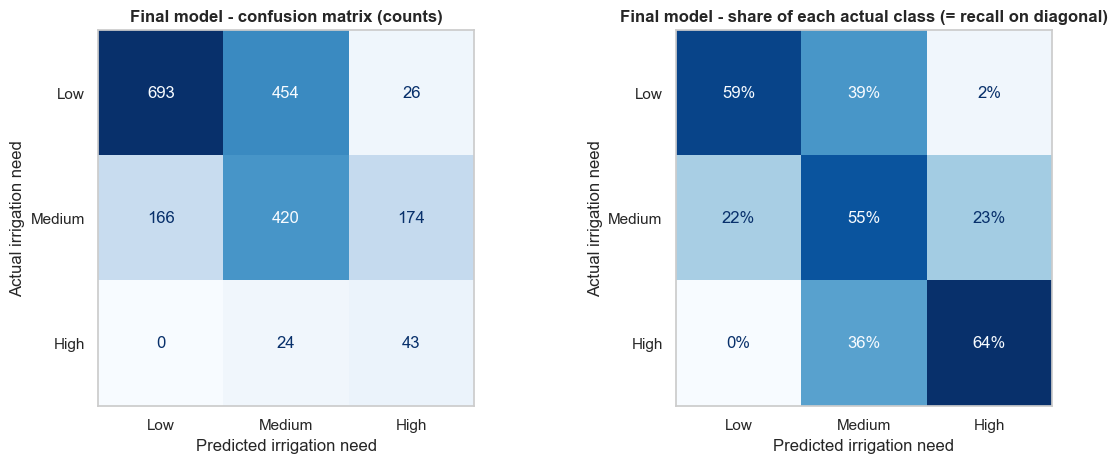

Trivial baseline (always predict 'Low') accuracy: 0.587
Final model accuracy: 0.578


In [46]:
# One-time confirmation on the untouched test set
final_test_pred = final_pipeline.predict(X_test)
print(f"Final model: {FINAL_NAME}\n")
print(classification_report(y_test, final_test_pred, labels=CLASS_ORDER, digits=3, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
ConfusionMatrixDisplay.from_predictions(y_test, final_test_pred, labels=CLASS_ORDER, cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Final model - confusion matrix (counts)"); axes[0].grid(False)
ConfusionMatrixDisplay.from_predictions(y_test, final_test_pred, labels=CLASS_ORDER, normalize="true", values_format=".0%",
                                        cmap="Blues", ax=axes[1], colorbar=False)
axes[1].set_title("Final model - share of each actual class (= recall on diagonal)"); axes[1].grid(False)
for ax in axes: ax.set_xlabel("Predicted irrigation need"); ax.set_ylabel("Actual irrigation need")
plt.tight_layout(); plt.show()

# Test-set score of the final model vs. a trivial baseline
majority_baseline = (y_test == y_train.mode()[0]).mean()
print(f"Trivial baseline (always predict '{y_train.mode()[0]}') accuracy: {majority_baseline:.3f}")
print(f"Final model accuracy: {accuracy_score(y_test, final_test_pred):.3f}")

**Why this model was selected.**

* In cross-validation on the training set, the balanced Decision Tree and balanced Random Forest are effectively tied (macro-F1 0.511 vs 0.510; High recall 0.699 vs 0.695). Both are clearly ahead of the other four models on cross-validated macro-F1 (0.43–0.46).
* Because the two are within noise of each other, the pre-declared rule falls to simplicity: the selected **Decision Tree (balanced, max depth 2)** is a rule set of four leaves that can be read by a person and even written as a few `if` statements on a microcontroller, whereas the Random Forest needs 150 trees.
* **Test-set confirmation (used once):** accuracy 0.578, macro-F1 0.489, *High* recall 0.642 (≈ 43 of 67 High observations found), *High* precision 0.177, *Medium* recall 0.553, *Low* recall 0.591.

**Honest caveats.**
* The final accuracy (0.578) is **not higher than the trivial "always Low" baseline (0.587)**. The model is chosen for what it does for the *High* and *Medium* classes, not for accuracy.
* Only ≈ 18 % of *High* alerts are correct, so this model should be viewed as a **screening tool**, not a precise classifier.
* Test-set results for the other models were not used to choose between models.

### 14.1 Pump decision view (derived from the 3-class prediction)

The pump needs a yes/no decision. The dataset does not say which levels should trigger irrigation, so this is an **explicit design assumption**, defined once and editable:

| Predicted level | Pump recommendation (default) |
|---|---|
| Low | Irrigation Not Needed |
| Medium | Irrigation Needed |
| High | Irrigation Needed |

Change `IRRIGATION_POLICY` if the agronomist decides that only *High* should start the pump.


In [47]:
IRRIGATION_POLICY = {"Low": "Irrigation Not Needed", "Medium": "Irrigation Needed", "High": "Irrigation Needed"}

y_test_binary = y_test.map(IRRIGATION_POLICY)
pred_binary = pd.Series(final_test_pred, index=y_test.index).map(IRRIGATION_POLICY)
print("Pump-decision performance of the final model (test set):")
print(classification_report(y_test_binary, pred_binary, digits=3, zero_division=0))
binary_cm = confusion_matrix(y_test_binary, pred_binary, labels=["Irrigation Not Needed", "Irrigation Needed"])
display(pd.DataFrame(binary_cm, index=["Actual: Not Needed", "Actual: Needed"], columns=["Pred: Not Needed", "Pred: Needed"]))
binary_metrics = classification_report(y_test_binary, pred_binary, output_dict=True, zero_division=0)["Irrigation Needed"]

Pump-decision performance of the final model (test set):
                       precision    recall  f1-score   support

    Irrigation Needed      0.579     0.799     0.672       827
Irrigation Not Needed      0.807     0.591     0.682      1173

             accuracy                          0.677      2000
            macro avg      0.693     0.695     0.677      2000
         weighted avg      0.713     0.677     0.678      2000



,Pred: Not Needed,Pred: Needed
Actual: Not Needed,693,480
Actual: Needed,166,661


**Interpretation (pump decision under the default policy).** With *Medium* and *High* both triggering irrigation, the model recommends irrigation for **79.9 %** of the fields that truly needed it (recall 0.799), missing 166 of 827. When it recommends irrigation it is right 57.9 % of the time; it triggers 480 unnecessary irrigations among 1,173 fields that did not need it. So the model leans toward **over-irrigating rather than under-irrigating**, which fits the aim of avoiding under-irrigation, but wastes water. If the policy is changed (for example, only *High* starts the pump) these numbers will change and should be re-evaluated.

## Step 15 — Feature Importance / Model Interpretation

Two complementary views are used:

1. **Model-internal importance** – coefficients for Logistic Regression, or impurity-based `feature_importances_` for tree models.
2. **Permutation importance** (model-agnostic) – shuffle one feature at a time on the test set and measure how much macro-F1 drops. A big drop means the model relies on that feature.

**Caution:** importance describes what *this model* uses to separate the classes in *this dataset*. It does **not** prove that a variable *causes* irrigation need.


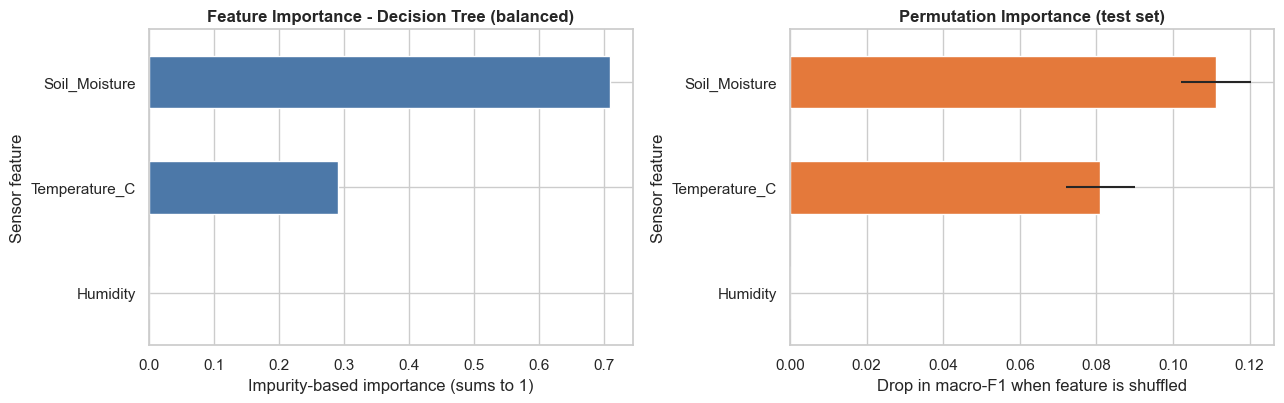

,model_importance,permutation_drop_in_macroF1
Soil_Moisture,0.7094,0.1112
Temperature_C,0.2906,0.0810
Humidity,0.0000,0.0000



Learned decision rules:

|--- Soil_Moisture <= 24.98
|   |--- Temperature_C <= 30.06
|   |   |--- class: Medium
|   |--- Temperature_C >  30.06
|   |   |--- class: High
|--- Soil_Moisture >  24.98
|   |--- Temperature_C <= 30.16
|   |   |--- class: Low
|   |--- Temperature_C >  30.16
|   |   |--- class: Medium



In [48]:
clf = final_pipeline.named_steps["clf"]
if hasattr(clf, "feature_importances_"):
    internal = pd.Series(clf.feature_importances_, index=FEATURES)
    internal_label = "Impurity-based importance (sums to 1)"
elif hasattr(clf, "coef_"):
    coef_table = pd.DataFrame(clf.coef_, index=clf.classes_, columns=FEATURES).reindex(CLASS_ORDER)
    print("Logistic-regression coefficients on STANDARDISED features (per class, log-odds per 1 std):")
    display(coef_table.round(3))
    internal = coef_table.abs().mean()
    internal_label = "Mean |coefficient| across classes (standardised features)"

perm = permutation_importance(final_pipeline, X_test, y_test, scoring="f1_macro", n_repeats=30, random_state=RANDOM_STATE)
perm_df = pd.DataFrame({"mean": perm.importances_mean, "std": perm.importances_std}, index=FEATURES)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
internal.sort_values().plot(kind="barh", ax=axes[0], color="#4C78A8")
axes[0].set_title(f"Feature Importance - {FINAL_NAME}"); axes[0].set_xlabel(internal_label); axes[0].set_ylabel("Sensor feature")
perm_df["mean"].sort_values().plot(kind="barh", xerr=perm_df.loc[perm_df["mean"].sort_values().index, "std"], ax=axes[1], color="#E4793B")
axes[1].set_title("Permutation Importance (test set)"); axes[1].set_xlabel("Drop in macro-F1 when feature is shuffled"); axes[1].set_ylabel("Sensor feature")
plt.tight_layout(); plt.show()
display(pd.DataFrame({"model_importance": internal, "permutation_drop_in_macroF1": perm_df["mean"]}).round(4))

if isinstance(clf, DecisionTreeClassifier):
    print("\nLearned decision rules:\n")
    print(export_text(clf, feature_names=FEATURES, max_depth=4))

**Interpretation.**
* **Soil moisture** is the most important input (impurity importance 0.71; shuffling it lowers macro-F1 by about 0.11).
* **Temperature** is second (0.29; drop of about 0.08).
* **Humidity is not used at all** by the selected tree (importance 0.00; shuffling it changes nothing). This agrees with the earlier plots, where humidity had no visible relationship with the target.
* The learned rules are simple: soil moisture ≤ ≈ 25 % and temperature > ≈ 30 °C → *High*; soil moisture ≤ 25 % and cooler → *Medium*; soil moisture > 25 % and cooler → *Low*; soil moisture > 25 % and hotter → *Medium*.

These importances describe what the model uses in this dataset. They do **not** prove that soil moisture or temperature cause irrigation need, and they say nothing about humidity's role in real fields.

### 15.1 Diagnostic — how much does using only three sensors cost?

This is a **reference experiment, not the project model**. To understand the ceiling on performance, the same train/test split is used to train a Random Forest on *all* dataset columns (categorical ones one-hot encoded). It is used only to quantify what the three-sensor restriction gives up and is **not** used for model selection or deployment.


,accuracy,macro_f1,recall_High,precision_High,recall_Medium,recall_Low
Final model (3 sensors),0.578,0.489,0.642,0.177,0.553,0.591
Reference RF (all columns),0.972,0.854,0.433,1.000,0.979,0.999


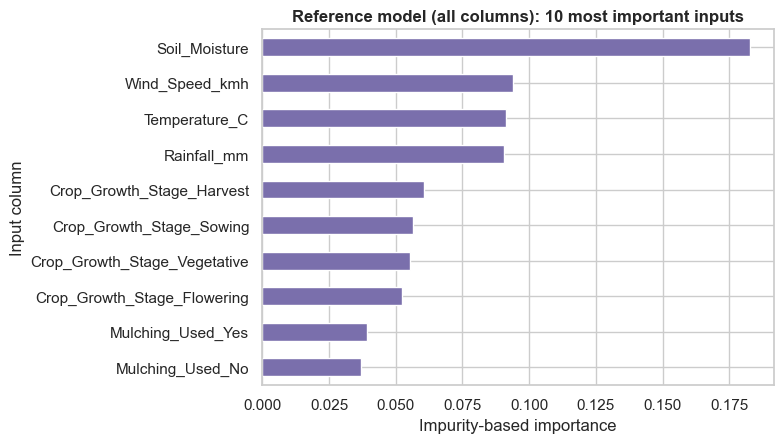

In [49]:
all_features = [c for c in df.columns if c != TARGET_COL]
cat_cols = df[all_features].select_dtypes(exclude="number").columns.tolist()
num_cols = [c for c in all_features if c not in cat_cols]

pre = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)], remainder="passthrough")
ref_model = Pipeline([("pre", pre), ("clf", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=1))])
Xa_train, Xa_test = df.loc[X_train.index, all_features], df.loc[X_test.index, all_features]
ref_model.fit(Xa_train, y_train)
ref_pred = ref_model.predict(Xa_test)

ref_vs_final = pd.DataFrame({"Final model (3 sensors)": summarize(y_test, final_test_pred),
                             "Reference RF (all columns)": summarize(y_test, ref_pred)}).T
display(ref_vs_final[["accuracy", "macro_f1", "recall_High", "precision_High", "recall_Medium", "recall_Low"]].round(3))

ref_names = ref_model.named_steps["pre"].get_feature_names_out()
ref_imp = pd.Series(ref_model.named_steps["clf"].feature_importances_, index=[n.split("__")[-1] for n in ref_names])
top = ref_imp.sort_values(ascending=False).head(10)
ax = top.sort_values().plot(kind="barh", figsize=(8, 4.6), color="#7A6FAC")
ax.set_title("Reference model (all columns): 10 most important inputs"); ax.set_xlabel("Impurity-based importance"); ax.set_ylabel("Input column")
plt.tight_layout(); plt.show()

**Interpretation.** A Random Forest given **all** columns reaches accuracy ≈ 0.97 and macro-F1 ≈ 0.85, compared with ≈ 0.58 and ≈ 0.49 for the three-sensor model. In that reference model soil moisture is still the strongest single input, followed by wind speed, temperature and rainfall (all with similar importance) and crop growth stage (split across its four one-hot columns). The limited performance of the final model is therefore explained mostly by **information that the three sensors do not provide**, not by a shortcoming of the algorithm.

Two cautions: (1) the reference model detects fewer *High* cases (recall ≈ 0.43) but is almost never wrong when it says *High* (precision ≈ 1.0), a different trade-off from the final model; (2) this comparison shows what the dataset's label depends on; it does not show that the extra variables would be practical or reliable to measure in a real deployment (for example, a seasonal rainfall total is not a live sensor value). It also suggests the label may follow a fixed rule involving several variables, consistent with generated data.

## Step 16 — Visualize Predictions

Actual vs predicted irrigation status for the test set, including the probabilities the final model assigns (all three candidate families support `predict_proba`).


In [50]:
proba = final_pipeline.predict_proba(X_test)
proba_df = pd.DataFrame(proba, columns=[f"P({c})" for c in final_pipeline.classes_], index=X_test.index)[[f"P({c})" for c in CLASS_ORDER]]

results = X_test.copy()
results["Actual"] = y_test
results["Predicted"] = final_test_pred
results = results.join(proba_df.round(3))
results["Correct?"] = np.where(results["Actual"] == results["Predicted"], "yes", "NO")

print("12 randomly chosen test observations:")
display(results.sample(12, random_state=RANDOM_STATE).reset_index(drop=True))

12 randomly chosen test observations:


,Soil_Moisture,Temperature_C,Humidity,Actual,Predicted,P(Low),P(Medium),P(High),Correct?
0,47.15,19.72,66.89,Low,Low,0.740,0.260,0.000,yes
1,60.57,38.72,52.15,Medium,Medium,0.402,0.439,0.159,yes
2,47.79,38.23,55.97,Medium,Medium,0.402,0.439,0.159,yes
3,11.48,14.25,89.21,Medium,Medium,0.168,0.499,0.332,yes
4,19.63,31.22,44.80,Medium,High,0.028,0.218,0.754,NO
5,47.82,14.03,33.49,Low,Low,0.740,0.260,0.000,yes
6,59.05,20.16,50.49,Low,Low,0.740,0.260,0.000,yes
7,29.47,34.15,36.38,Low,Medium,0.402,0.439,0.159,NO
8,42.65,37.77,83.06,Medium,Medium,0.402,0.439,0.159,yes
9,54.92,15.98,89.78,Low,Low,0.740,0.260,0.000,yes


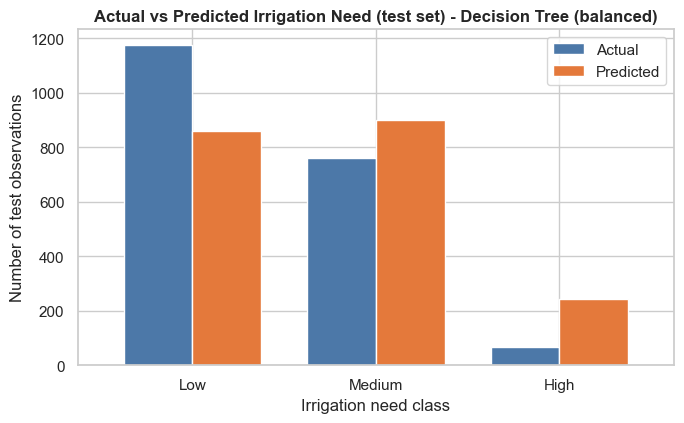

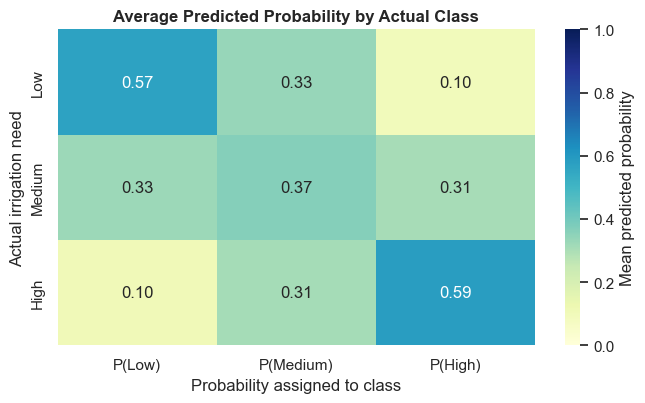

In [51]:
# Actual vs predicted counts
count_df = pd.DataFrame({"Actual": y_test.value_counts().reindex(CLASS_ORDER),
                         "Predicted": pd.Series(final_test_pred).value_counts().reindex(CLASS_ORDER)}).fillna(0)
ax = count_df.plot(kind="bar", figsize=(7, 4.4), color=["#4C78A8", "#E4793B"], width=0.75)
ax.set_title(f"Actual vs Predicted Irrigation Need (test set) - {FINAL_NAME}")
ax.set_xlabel("Irrigation need class"); ax.set_ylabel("Number of test observations"); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

# Mean predicted probability for each actual class
mean_prob = proba_df.groupby(y_test).mean().reindex(CLASS_ORDER)
fig, ax = plt.subplots(figsize=(6.8, 4.2))
sns.heatmap(mean_prob, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1, ax=ax, cbar_kws={"label": "Mean predicted probability"})
ax.set_title("Average Predicted Probability by Actual Class")
ax.set_xlabel("Probability assigned to class"); ax.set_ylabel("Actual irrigation need")
plt.tight_layout(); plt.show()

**Interpretation (each statement checked against the computed output).**
* **Predicted vs actual counts (test set):** the balanced model predicts *High* far more often than it occurs (243 predicted vs 67 actual), *Medium* somewhat more often (898 vs 760) and *Low* less often (859 vs 1,173). This over-prediction of the higher-need classes is the effect of class weighting and matches the low *High* precision (0.18).
* **Probability heatmap:** for every actual class the highest average probability is assigned to the correct class (Low 0.57, Medium 0.37, High 0.59), but the margins are small for *Medium* (0.37 vs 0.33 for *Low*). *Medium* and *High* observations both receive substantial probability for neighbouring classes, reflecting the overlap seen in the EDA.
* **Only four distinct probability patterns exist,** because a depth-2 tree has four leaves (visible in the table, e.g. 0.740 / 0.260 / 0.000). Confidence is therefore coarse and step-like.
* **Probabilities are not calibrated frequencies.** With class weighting, the leaf that outputs P(High) = 0.754 (soil moisture ≤ 25 % and temperature > 30 °C) actually contains about 20 % *High* observations in the raw data (about 68 % *Medium*, 13 % *Low*). Read them as relative confidence only.

## Step 17 — Test the Model With New Sensor Values

`predict_irrigation()` takes the three sensor readings, builds the input in the **saved feature order**, passes it through the trained pipeline (scaler + model, nothing hard-coded), and returns the pump recommendation. `predict_irrigation_detailed()` also returns the predicted level and class probabilities.

Input checks: physically impossible values raise an error, and values outside the range seen in training produce a warning, because the model can only be trusted inside the conditions it learned from.


In [52]:
TRAIN_RANGES = {c: (float(X_train[c].min()), float(X_train[c].max())) for c in FEATURES}

def predict_irrigation_detailed(soil_moisture, temperature, humidity, model=None):
    """Return predicted irrigation level, probabilities, pump recommendation and warnings."""
    model = model or final_pipeline
    values = {SOIL_COL: soil_moisture, TEMP_COL: temperature, HUM_COL: humidity}
    for col, v in values.items():
        lo, hi = PHYSICAL_LIMITS[col]
        if v is None or not np.isfinite(v) or not lo <= v <= hi:
            raise ValueError(f"{col}={v} is outside the physically valid range {lo} to {hi}.")
    notes = [f"{c}={v} is outside the training range {TRAIN_RANGES[c][0]:.0f}-{TRAIN_RANGES[c][1]:.0f}; treat prediction with caution."
             for c, v in values.items() if not TRAIN_RANGES[c][0] <= v <= TRAIN_RANGES[c][1]]
    x_new = pd.DataFrame([[values[c] for c in FEATURES]], columns=FEATURES)   # same feature order as training
    level = model.predict(x_new)[0]
    probs = dict(zip(model.classes_, model.predict_proba(x_new)[0].round(3)))
    return {"predicted_level": level, "probabilities": {c: float(probs[c]) for c in CLASS_ORDER},
            "decision": IRRIGATION_POLICY[level], "warnings": notes}

def predict_irrigation(soil_moisture, temperature, humidity):
    """Return 'Irrigation Needed' or 'Irrigation Not Needed'."""
    return predict_irrigation_detailed(soil_moisture, temperature, humidity)["decision"]

print(predict_irrigation(soil_moisture=30, temperature=32, humidity=55))
print(predict_irrigation_detailed(soil_moisture=30, temperature=32, humidity=55))

Irrigation Needed
{'predicted_level': 'Medium', 'probabilities': {'Low': 0.402, 'Medium': 0.439, 'High': 0.159}, 'decision': 'Irrigation Needed', 'warnings': []}


## Step 18 — Simulate Sensor Data

> **These are test inputs / simulation only — not real sensor measurements.** No physical sensor was connected. The values are hand-picked to show how a reading would flow through the model.


In [53]:
simulated_readings = [
    ("Moderate soil moisture, hot",       30, 32, 55),
    ("Wet soil, mild",                    55, 22, 70),
    ("Dry soil, cool, humid",             12, 18, 85),
    ("Borderline soil moisture",          26, 28, 60),
    ("Dry and hot",                       10, 40, 30),
    ("Well watered and hot",              60, 38, 40),
    ("Out-of-range humidity (warning)",   40, 25, 100),
]
first = True
rows = []
for label, sm, t, h in simulated_readings:
    r = predict_irrigation_detailed(sm, t, h)
    if first:
        print("SIMULATION - example readout\n")
        print(f"Soil Moisture: {sm}%\nTemperature: {t}°C\nHumidity: {h}%\n\nPrediction: {r['decision']}   (level: {r['predicted_level']})\n")
        first = False
    rows.append({"Scenario (simulated)": label, "Soil moisture %": sm, "Temp °C": t, "Humidity %": h,
                 "Predicted level": r["predicted_level"], "Decision": r["decision"],
                 "P(Low)": r["probabilities"]["Low"], "P(Medium)": r["probabilities"]["Medium"], "P(High)": r["probabilities"]["High"],
                 "Warning": "; ".join(r["warnings"]) or "-"})
display(pd.DataFrame(rows))

SIMULATION - example readout

Soil Moisture: 30%
Temperature: 32°C
Humidity: 55%

Prediction: Irrigation Needed   (level: Medium)



,Scenario (simulated),Soil moisture %,Temp °C,Humidity %,Predicted level,Decision,P(Low),P(Medium),P(High),Warning
0,"Moderate soil moisture, hot",30,32,55,Medium,Irrigation Needed,0.402,0.439,0.159,-
1,"Wet soil, mild",55,22,70,Low,Irrigation Not Needed,0.740,0.260,0.000,-
2,"Dry soil, cool, humid",12,18,85,Medium,Irrigation Needed,0.168,0.499,0.332,-
3,Borderline soil moisture,26,28,60,Low,Irrigation Not Needed,0.740,0.260,0.000,-
4,Dry and hot,10,40,30,High,Irrigation Needed,0.028,0.218,0.754,-
5,Well watered and hot,60,38,40,Medium,Irrigation Needed,0.402,0.439,0.159,-
6,Out-of-range humidity (warning),40,25,100,Low,Irrigation Not Needed,0.740,0.260,0.000,Humidity=100 is outside the training range 25-...


**Interpretation of the simulation (test inputs, not real sensor data).**
* The example reading (30 % soil moisture, 32 °C, 55 % humidity) is predicted *Medium* → **Irrigation Needed**, with low confidence (P(Medium) 0.44 vs P(Low) 0.40).
* Very dry and hot (10 %, 40 °C) gives *High* with the highest confidence (0.75).
* Borderline behaviour follows the tree's threshold: 26 % soil moisture at 28 °C is *Low*, whereas soil moisture at or below about 25 % at the same temperature is *Medium*.
* **A limitation this exposes:** the "well watered and hot" input (60 %, 38 °C) is predicted *Medium* → Irrigation Needed. In the raw data, observations with soil moisture above 25 % and temperature above 30 °C are about **58 % Low, 40 % Medium and 1 % High**, so *Low* is actually the more common outcome there. The balanced model still outputs *Medium* because class weighting pushes the leaf toward the higher-need class. This is a deliberate bias toward avoiding under-irrigation, but it means the model will recommend some unnecessary irrigation, and safety/agronomic rules outside the model are needed.
* Humidity has no effect on this model's output (it is unused by the tree), and a value of 100 % triggers an out-of-training-range warning (training range 25–95 %).

## Step 19 — IoT Deployment Concept

**Proposed architecture (concept only — not built or tested in this notebook):**

```text
Soil Moisture Sensor ─┐
                      │
Temperature Sensor ───┼──> Microcontroller
                      │
Humidity Sensor ──────┘
                              │
                              ↓
                         Sensor Data
                              │
                              ↓
                         AI Model
                              │
                    ┌─────────┴─────────┐
                    ↓                   ↓
             Irrigation ON       Irrigation OFF
                    │                   │
                    ↓                   ↓
                Water Pump            Pump OFF
```

**Possible hardware:** an **ESP32** (built-in Wi-Fi) or an **Arduino-compatible** board, depending on availability, with a capacitive soil-moisture probe, a DHT22/BME280-type temperature-humidity sensor, and a relay module switching the pump.

**Two ways to run the model:**

| Option | How | Trade-off |
|---|---|---|
| **Edge / on-device** | Export the (small) decision-tree or logistic-regression rules into C/C++ code running on the microcontroller | Works offline; only feasible for small models |
| **Edge + server** | The microcontroller sends readings over Wi-Fi (e.g. HTTP/MQTT) to a Python service that loads the saved model and returns the decision | Any scikit-learn model can be used; requires connectivity |

**Points that must be handled before real deployment**
* **Calibration** – the moisture probe's raw output (voltage/ADC counts) must be calibrated to the same scale (%) as the dataset; this is a major source of error.
* **Sensor faults** – readings outside valid ranges (as checked in `predict_irrigation`) must be rejected, and averaging over several readings reduces noise.
* **Safety logic** – add a maximum pump run-time, minimum interval between cycles and a manual override, independent of the model.
* **Validation** – compare model decisions with real field observations before letting it control the pump automatically.

> Hardware integration has **not** been implemented or tested in this notebook.


## Step 20 — Save the Model

Training takes time and depends on the data; the deployed system should not retrain at start-up. Saving the fitted pipeline lets an application or gateway load exactly the model evaluated here. The saved pipeline already **contains the fitted scaler (or pass-through) and the classifier**, so preprocessing cannot get out of sync with the model. The **feature order** and other metadata are stored alongside it as JSON.


In [54]:
ARTIFACT_DIR = Path("model_artifacts"); ARTIFACT_DIR.mkdir(exist_ok=True)
MODEL_PATH, META_PATH = ARTIFACT_DIR / "irrigation_model.joblib", ARTIFACT_DIR / "model_metadata.json"

joblib.dump(final_pipeline, MODEL_PATH)

metadata = {
    "project": "AI-Based Smart Irrigation System Using Environmental Sensor Data",
    "created": datetime.now().isoformat(timespec="seconds"),
    "model_name": FINAL_NAME,
    "model_parameters": {k: (None if v is None else v) for k, v in best_params[FINAL_NAME].items()},
    "feature_order": FEATURES,
    "feature_units": {SOIL_COL: "% (assumed)", TEMP_COL: "degrees Celsius", HUM_COL: "% relative humidity (assumed)"},
    "target": TARGET_COL,
    "classes": CLASS_ORDER,
    "irrigation_policy": IRRIGATION_POLICY,
    "training_value_ranges": TRAIN_RANGES,
    "physical_limits": PHYSICAL_LIMITS,
    "n_train": int(len(X_train)), "n_test": int(len(X_test)), "random_state": RANDOM_STATE,
    "test_metrics": {k: round(float(v), 4) for k, v in summarize(y_test, final_test_pred).items()},
    "library_versions": {"python": platform.python_version(), "scikit-learn": sklearn.__version__,
                         "pandas": pd.__version__, "numpy": np.__version__, "joblib": joblib.__version__},
    "notes": "Trained on the supplied dataset (source and collection method not documented). Not validated on real sensor data.",
}
META_PATH.write_text(json.dumps(metadata, indent=2, default=str))

# Verify: reload and confirm identical predictions
reloaded = joblib.load(MODEL_PATH)
assert (reloaded.predict(X_test) == final_pipeline.predict(X_test)).all()
print("Saved:", MODEL_PATH, "and", META_PATH, "- reload check passed (identical predictions).")
print("\nHow to use later:\n  model = joblib.load('model_artifacts/irrigation_model.joblib')\n  model.predict(pd.DataFrame([[soil, temp, hum]], columns=feature_order))")

Saved: model_artifacts\irrigation_model.joblib and model_artifacts\model_metadata.json - reload check passed (identical predictions).

How to use later:
  model = joblib.load('model_artifacts/irrigation_model.joblib')
  model.predict(pd.DataFrame([[soil, temp, hum]], columns=feature_order))


## Step 21 — Final Results Dashboard

,Value
Observations (after cleaning),"10,000"
Model input features,"3 (Soil_Moisture, Temperature_C, Humidity)"
Training size,"8,000"
Testing size,"2,000"
Target,Irrigation_Need: Low / Medium / High (origina...
Selected algorithm,"Decision Tree (balanced) {'max_depth': 2, 'mi..."
Accuracy,0.578
Precision (macro),0.484
Recall (macro),0.595
F1-score (macro),0.489


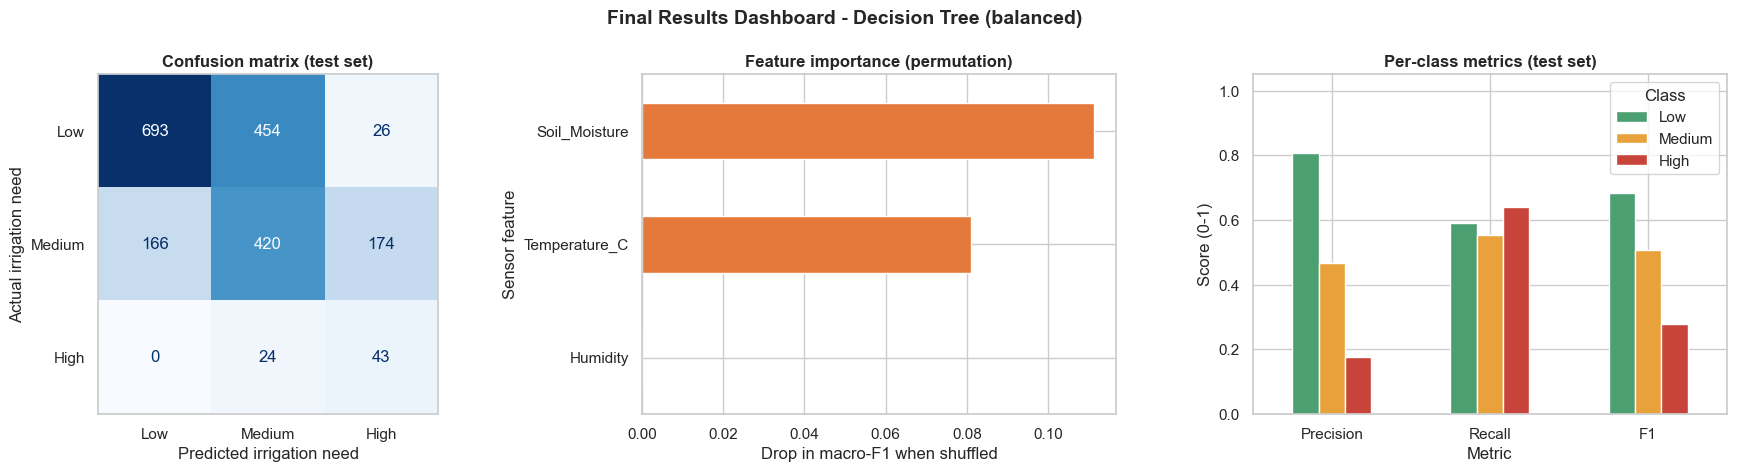

In [55]:
final_metrics = summarize(y_test, final_test_pred)
dashboard = pd.DataFrame({"Value": {
    "Observations (after cleaning)": f"{len(df):,}",
    "Model input features": f"{len(FEATURES)}  ({', '.join(FEATURES)})",
    "Training size": f"{len(X_train):,}",
    "Testing size": f"{len(X_test):,}",
    "Target": f"{TARGET_COL}: {' / '.join(CLASS_ORDER)}  (original dataset labels)",
    "Selected algorithm": f"{FINAL_NAME}  {best_params[FINAL_NAME]}",
    "Accuracy": f"{final_metrics['accuracy']:.3f}",
    "Precision (macro)": f"{final_metrics['macro_precision']:.3f}",
    "Recall (macro)": f"{final_metrics['macro_recall']:.3f}",
    "F1-score (macro)": f"{final_metrics['macro_f1']:.3f}",
    "Recall - High class": f"{final_metrics['recall_High']:.3f}",
    "Precision - High class": f"{final_metrics['precision_High']:.3f}",
    "Pump-decision recall (Needed)": f"{binary_metrics['recall']:.3f}",
    "Pump-decision precision (Needed)": f"{binary_metrics['precision']:.3f}",
}})
display(dashboard)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
ConfusionMatrixDisplay.from_predictions(y_test, final_test_pred, labels=CLASS_ORDER, cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Confusion matrix (test set)"); axes[0].set_xlabel("Predicted irrigation need"); axes[0].set_ylabel("Actual irrigation need"); axes[0].grid(False)
perm_df["mean"].sort_values().plot(kind="barh", ax=axes[1], color="#E4793B")
axes[1].set_title("Feature importance (permutation)"); axes[1].set_xlabel("Drop in macro-F1 when shuffled"); axes[1].set_ylabel("Sensor feature")
per_cls = pd.DataFrame({c: [final_metrics[f"precision_{c}"], final_metrics[f"recall_{c}"], final_metrics[f"f1_{c}"]] for c in CLASS_ORDER}, index=["Precision", "Recall", "F1"])
per_cls.plot(kind="bar", ax=axes[2], color=[CLASS_COLORS[c] for c in CLASS_ORDER]); axes[2].set_ylim(0, 1.05)
axes[2].set_title("Per-class metrics (test set)"); axes[2].set_xlabel("Metric"); axes[2].set_ylabel("Score (0-1)"); plt.setp(axes[2].get_xticklabels(), rotation=0)
axes[2].legend(title="Class")
plt.suptitle(f"Final Results Dashboard - {FINAL_NAME}", fontsize=14, fontweight="bold"); plt.tight_layout(); plt.show()

## Step 22 — Conclusion

**What was built.** A complete machine-learning prototype in this notebook: data inspection and cleaning, exploratory analysis, six candidate models (Logistic Regression, Decision Tree and Random Forest, each with and without class weighting), cross-validated model selection, evaluation on an untouched test set, a prediction function, a simulation and a saved model with metadata.

**What the model predicts.** The dataset's own three-level label `Irrigation_Need` (**Low / Medium / High**), from three inputs: **soil moisture, temperature and humidity**. A pump recommendation ("Irrigation Needed" / "Not Needed") is derived from the predicted level by an explicit, editable rule (Medium and High → irrigate), which is a design assumption and not something the dataset defines.

**Selected model and performance.** A balanced **Decision Tree of depth 2**. On the 2,000-row test set: accuracy 0.578, macro-F1 0.489, recall for *High* 0.642 (precision 0.177). As a pump decision, it finds ≈ 80 % of the fields that needed irrigation (precision ≈ 58 %). The model relies on soil moisture (threshold ≈ 25 %) and temperature (threshold ≈ 30 °C); humidity is not used.

**How it could support smart irrigation.** As a low-cost screening rule that flags dry, hot conditions and errs toward irrigating rather than under-irrigating, and which is simple enough to run on a microcontroller or a small server.

**Limitations.**
* **Modest performance:** accuracy is no better than always predicting "Low" (0.587), and only ≈ 18 % of *High* alerts are correct. The result must not be presented as a highly accurate system.
* **Missing information:** a model using all dataset columns reaches ≈ 0.97 accuracy, so the three sensors leave much of the label unexplained.
* **Data origin:** the flat distributions, hard limits and uncorrelated variables suggest simulated data; its source, units and labelling method are undocumented. Patterns (e.g. the 25 % soil-moisture threshold) may reflect the generator, not real agronomy.
* **Small rare class:** only 67 *High* examples in the test set, so *High* metrics are uncertain.
* **No geography:** the dataset has no coordinates, so no map could be produced.
* **Uncalibrated probabilities** (class weighting) and coarse, four-leaf outputs.

**How real sensor data would help.** Collecting readings from the actual sensors, together with an expert's or an outcome-based irrigation decision, would allow (1) calibrating the sensors against this scale, (2) re-training and testing on the true operating conditions, (3) checking whether humidity or additional inputs (e.g. rainfall or a weather forecast, crop stage) are worth adding, and (4) choosing the irrigation policy and alert threshold with agronomists.

**Path to controlling a water pump.** Load the saved model (`model_artifacts/`), feed it validated sensor readings from an ESP32/Arduino-class node, and drive a relay through the decision, with safeguards independent of the model (maximum run time, minimum interval, manual override).

> **Prototype vs deployment.** Everything in this notebook is a **machine-learning prototype trained and tested on a supplied dataset**. No sensor, microcontroller or pump has been connected or tested. Physical IoT deployment is a **future stage** that requires hardware integration and field validation.


###TESTING REAL DATA

In [1]:
import pandas as pd
import joblib

# Load real sensor data
real_data = pd.read_csv("real_sensor_data.csv")

# Display the first readings
real_data.head()

,Timestamp,Soil_Moisture,Temperature_C,Humidity
0,2026-09-30 20:58:55,0.2,25.6,89.1
1,2026-09-30 20:58:57,0.2,25.7,89.6
2,2026-09-30 20:58:59,0.5,25.7,89.6
3,2026-09-30 20:59:01,0.2,25.7,89.3
4,2026-09-30 20:59:03,0.2,25.7,89.3


In [2]:
real_data.describe()

,Soil_Moisture,Temperature_C,Humidity
count,135.000000,135.000000,135.000000
mean,3.142222,25.745926,89.619259
std,14.571289,0.051490,0.281387
min,0.000000,25.600000,89.100000
25%,0.000000,25.700000,89.300000
50%,0.200000,25.700000,89.700000
75%,0.200000,25.800000,89.800000
max,100.000000,25.800000,90.100000


In [3]:
model = joblib.load("model_artifacts/irrigation_model.joblib")

print("Model loaded successfully.")

Model loaded successfully.


In [7]:
features = [
    "Soil_Moisture",
    "Temperature_C",
    "Humidity"
]

predictions = model.predict(real_data[features])

real_data["Irrigation_Need"] = predictions

real_data.head(5)

,Timestamp,Soil_Moisture,Temperature_C,Humidity,Irrigation_Need
0,2026-09-30 20:58:55,0.2,25.6,89.1,Medium
1,2026-09-30 20:58:57,0.2,25.7,89.6,Medium
2,2026-09-30 20:58:59,0.5,25.7,89.6,Medium
3,2026-09-30 20:59:01,0.2,25.7,89.3,Medium
4,2026-09-30 20:59:03,0.2,25.7,89.3,Medium


In [8]:
real_data["Pump_Action"] = real_data["Irrigation_Need"].map({
    "Low": "OFF",
    "Medium": "ON",
    "High": "ON"
})

real_data.head(10)

,Timestamp,Soil_Moisture,Temperature_C,Humidity,Irrigation_Need,Pump_Action
0,2026-09-30 20:58:55,0.2,25.6,89.1,Medium,ON
1,2026-09-30 20:58:57,0.2,25.7,89.6,Medium,ON
2,2026-09-30 20:58:59,0.5,25.7,89.6,Medium,ON
3,2026-09-30 20:59:01,0.2,25.7,89.3,Medium,ON
4,2026-09-30 20:59:03,0.2,25.7,89.3,Medium,ON
5,2026-09-30 20:59:05,0.0,25.7,89.3,Medium,ON
6,2026-09-30 20:59:07,0.0,25.7,89.3,Medium,ON
7,2026-09-30 20:59:09,0.5,25.7,89.3,Medium,ON
8,2026-09-30 20:59:11,0.2,25.7,89.3,Medium,ON
9,2026-09-30 20:59:13,0.0,25.8,89.2,Medium,ON


In [9]:
real_data["Irrigation_Need"].value_counts()

Irrigation_Need
Medium    129
Low         6
Name: count, dtype: int64

In [10]:
real_data["Pump_Action"].value_counts()

Pump_Action
ON     129
OFF      6
Name: count, dtype: int64

In [11]:
real_data[[
    "Soil_Moisture",
    "Temperature_C",
    "Humidity",
    "Irrigation_Need",
    "Pump_Action"
]].tail(20)

,Soil_Moisture,Temperature_C,Humidity,Irrigation_Need,Pump_Action
115,1.9,25.8,89.5,Medium,ON
116,46.3,25.8,89.5,Low,OFF
117,73.7,25.8,89.5,Low,OFF
118,0.5,25.8,89.5,Medium,ON
119,1.6,25.8,89.5,Medium,ON
120,0.6,25.8,89.5,Medium,ON
121,0.6,25.8,89.5,Medium,ON
122,11.8,25.8,89.5,Medium,ON
123,42.3,25.8,89.5,Low,OFF
124,0.2,25.8,89.5,Medium,ON
